# How new science concepts grow in a knowledge network — RQ1 precursor test (demo)

This notebook is a runnable walk-through of `method.py` from the experiment **"How new science concepts grow in a knowledge
network"** (iteration 2, network-only, no API calls).

**What the full experiment did.** It built 25 yearly co-word snapshots of science (2000–2024, 3-year windows,
~27k concept nodes, association-strength edge weights, Leiden communities with alluvial ids), attached a pool of 145
newly-born scientific concepts (123 *screen* + 22 stationary *reference* concepts), and computed 96 per-(concept, year)
network indicators using only data up to that year: weighted degree (strength) and its percentile, betweenness,
new-relation rate, neighbourhood novelty, Baselga turnover, accretion shift, Chung-Lu **closure**, **participation**
across communities, within-module z, community change, subfield count / entropy / Rao-Stirling diversity and a
Kleinberg burst state.

**What `method.py` (this notebook) does with those indicators** — the RQ1 test of *structural precursors of emergence*:

1. **Labels** — emergence `E(c,t)`: sustained uptake (≥20 papers/yr over t+1..t+5) **and** a ≥20-point gain in strength
   percentile; secondary labels `E_alt` (percentile among pool concepts only) and `E_up` (sustained uptake only).
2. **Matched event study** — each emerging concept vs. 1:3 volume-matched never-emerging concepts, looking at the 5 years
   before onset for the three pre-named precursors (accretion shift, closure, participation), with Holm correction,
   placebo, relaxed matching and a pooled-panel alternative.
3. **Rolling-origin prediction** — do the precursors add anything beyond frequency/burst + degree + entropy baselines?
4. **Structural patterns** (incubation→expansion, gradual centralisation, early bridging) and a **DTW k-medoids
   typology** of indicator trajectories with bootstrap stability.
5. Figures, `method_out.json` and verdicts.

**Demo scale.** The original stages that build the snapshots and indicators (`stage_prep/snapshots/indicators/robust.py`)
take hours and need ~150 MB of intermediates, so this notebook starts from the **precomputed indicator panel** for a
curated subset of **100 concepts**: the 90 screen concepts that enter the event study and pattern analysis (all
emerging and never-emerging concepts) + 10 of the 22 reference concepts. All bootstrap counts are at their original
values and the whole notebook runs in about a minute. The event-study, pattern and their verdicts reproduce the full run
exactly (e.g. closure before sustained uptake, E_up: S = −0.837, Holm p = 0.003). The prediction, typology and
reference-arm numbers differ slightly, because the 33 screen concepts outside the event-study window and 12 reference
concepts are not in the demo data.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0',
         'pyarrow==18.1.0', 'numba==0.60.0')

# loguru, tslearn (DTW), kmedoids (FasterPAM) — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3', 'tslearn==0.9.0', 'kmedoids==0.5.5')

## Imports

The original `method.py` import block, followed by the module-level imports of the helper modules it calls
(`config.py`, `lib_metrics.py`, `analysis_event.py`, `analysis_predict.py`, `analysis_patterns.py`), whose code is
reproduced in the cells below.

In [2]:
import os

os.environ.setdefault("OMP_NUM_THREADS", "1")  # avoid OpenMP oversubscription (HGB) when stages run side by side

import argparse
import json
import math
import subprocess
import sys
import time

import numpy as np
import pandas as pd
from loguru import logger

# --- imports of the helper modules (config.py, lib_metrics.py, analysis_*.py)
import hashlib
import resource
import warnings
from collections.abc import Iterable, Sequence
from pathlib import Path

from scipy.stats import fisher_exact, kendalltau
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import adjusted_mutual_info_score, average_precision_score, r2_score, roc_auc_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# --- notebook additions (visualisation)
import matplotlib.pyplot as plt
from IPython.display import Image, display

## Load the demo data

Loads `mini_demo_data.json` from GitHub, falling back to a local copy.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/main/round-2/experiment-3/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print({k: (len(v) if isinstance(v, (list, dict)) else v) for k, v in data.items() if k != "description"})

Mini demo data for the RQ1 concept-emergence analysis: 100 pool concepts (90 screen + 10 reference) with their yearly network indicators (one row per concept-year, data <= year), the pool table, the 25 yearly snapshot summaries and the alluvial community events.
{'pool': 100, 'indicators': 1894, 'indicator_columns': 96, 'sealed_ids': 61, 'snapshots': 25, 'alluvial_events': 4195, 'robustness': 6, 'indicator_summary': 6}


## Configuration

All tunable parameters are at the top, with the original values in the comments. They are set to the original values
(the notebook still finishes in about a minute on CPU); reduce them for a quicker smoke test (the minimum that still
yields CIs is `BOOTSTRAP=30, BOOT_CHECK=25, TYPOLOGY_BOOT=5, SHUFFLE_N=2`).

* `BOOTSTRAP` — concept-bootstrap replicates for every CI (event study, pooled panel, pattern differences, delta-AUC).
* `BOOT_CHECK` — replicates of the second bootstrap used for the CI-convergence check (500 vs 1000 in the original).
* `TYPOLOGY_BOOT` — bootstrap resamples for the k-medoids stability (Jaccard) of the DTW typology.
* `SHUFFLE_N` — label shuffles in the prediction shuffle-control.

Below them is the frozen analysis specification `SPEC` copied from `config.py` (thresholds, windows, matching rules,
test origins …) and the config helpers. `C`, `lm`, `AE`, `AP`, `APr` stand in for the original helper modules so that
the original call sites (`C.SPEC`, `lm.holm`, `AE.build_labels`, …) run unchanged. Outputs are written under
`demo_outputs/`.

In [5]:
# ---- tunable parameters (original values in comments)
BOOTSTRAP = 1000        # original: 1000
BOOT_CHECK = 500       # original: 500  (second bootstrap for the CI-convergence check)
TYPOLOGY_BOOT = 200    # original: 200
SHUFFLE_N = 20        # original: 20

# ---- output locations (the original wrote next to method.py; here everything goes to demo_outputs/)
ROOT = Path("demo_outputs").resolve()
WORK = ROOT / "work"                    # regenerable intermediates
OUT = ROOT / "results"
FIG = ROOT / "figures"
for _d in (WORK, OUT, FIG, ROOT / "logs"):
    _d.mkdir(parents=True, exist_ok=True)

SPEC: dict = dict(
    years=list(range(2000, 2025)), window=3, tag_min_score=0.3, min_level=1, kept_edge_min_raw=2,
    leiden=dict(type="RBConfiguration", resolution=1.0, seed=42, n_runs=5),
    alluvial_min_jaccard=0.3, alluvial_min_comm_size=5,
    topk_closure=20, closure_min_neighbours=5, rewire_n=20, rewire_snapshots=[2008, 2013, 2018],
    stability_resamples=20, stability_snapshots=[2008, 2013, 2018],
    betweenness_pivots=500, rarefy_m=10, rarefy_m_sensitivity=5, rarefy_draws=50,
    E_uptake_mean=20, E_max_fall=0.30, E_pct_gain=20, ages=[3, 8], t_max=2019,
    sealed_focal_years=[2016, 2017, 2018], screen_onset_years=list(range(2008, 2016)),
    match=dict(band=True, origin_group=True, vol_caliper=0.20, widen=0.30, ratio=3, replace=True),
    bootstrap=BOOTSTRAP, holm_precursors=["accretion_shift_rar", "closure", "P_rar"],
    precursor_signs={"accretion_shift_rar": "+", "closure": "+", "P_rar": "+"},
    es_rel_years=list(range(-5, 1)), es_summary_window=[-3, 0],
    test_origins=[2013, 2014, 2015, 2019], min_train_rows=30, min_train_pos=5,
    h3_test_origins=[2011, 2012, 2013, 2014, 2015, 2019],
    frame_types=["article", "review", "preprint", "book-chapter"],
    kleinberg=dict(s=2.0, gamma=1.0),
    sensitivity_grid=dict(uptake=[10, 20, 30], pct_gain=[10, 20, 30]),
    early_bridging=dict(P_raw=0.6, btw_pct=90, min_comm_share=0.10, min_comms=2),
    gradual_centralisation=dict(min_len=3, tau=0.5, P_max=0.3),
    incubation=dict(min_run=2, burst_pct=90),
    typology=dict(channels=["strength_growth", "beta_sim_rar", "beta_sne_rar", "P_rar", "closure", "btw_pct", "H"],
                  ages=list(range(0, 9)), max_missing=3, max_fill=2, k_range=[2, 3, 4, 5, 6],
                  sakoe_chiba_radius=2, boot=TYPOLOGY_BOOT, jaccard_min=0.75),
    clarifications=[
        "(i) kept-graph edges = >= 2 RAW sample co-occurrences in the 3-year window (weighted c_ij >= 2 is non-binding because "
        "design weights are >= 1, median 293); strengths use ALL edges.",
        "(ii) background-comparable pool quantities (strength, strength percentile, association strength, closure neighbour "
        "set, within-module z, betweenness attachment) use frame-type c-papers (article, review, preprint, book-chapter); "
        "volume, uptake, neighbourhood turnover (Baselga, novelty), participation/community touch and disciplinary "
        "diversity/incidence use all c-paper types.",
        "(iii) works with topic_score < 0.05 (default-topic hazard H1) get subfield 'unknown' in the concept-subfield view "
        "only and are excluded from diversity measures; they stay in the co-word network.",
        "(iv) 'cross-community betweenness' (early bridging) = betweenness percentile >= 90 on the kept graph AND the node's "
        "frame-type tag weight touches >= 2 communities with >= 10% each.",
        "(v) background yearly weights are post-stratified w_year = n_frame(s,y)/n_sampled(s,y); design weight is the "
        "fallback when a subfield-year has no post-stratification cell.",
        "(vi) residualised (_res) indicator versions are fit on the full screen panel and are used only in the event "
        "study, never as prediction features (avoids pooled look-ahead).",
        "(vii) the pool concept strength percentile is computed among all nodes of snapshot y (background legacy concepts "
        "+ attached pool concepts); ALT percentile is among pool (screen+reference) nodes only.",
    ],
)

def spec_hash() -> str:
    return hashlib.sha256(json.dumps(SPEC, sort_keys=True).encode()).hexdigest()


def write_spec() -> str:
    h = spec_hash()
    (ROOT / "spec.json").write_text(json.dumps({"spec": SPEC, "sha256": h}, indent=1))
    return h


def setup_logging(name: str) -> None:
    logger.remove()
    logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{name}:{line}|{message}")
    logger.add(ROOT / "logs" / f"{name}.log", rotation="30 MB", level="DEBUG")


SEALED_IDS: set[str] = set()


def assert_not_sealed(concept_ids, focal_years=()) -> None:
    """Code guard: held-out concepts and sealed focal years never enter E/W2 computations."""
    bad = set(concept_ids) & SEALED_IDS
    if bad:
        raise RuntimeError(f"SEALED concept ids requested: {sorted(bad)[:5]}")
    bad_t = set(int(t) for t in focal_years) & set(SPEC["sealed_focal_years"])
    if bad_t:
        raise RuntimeError(f"SEALED focal years requested: {sorted(bad_t)}")


class _NotebookModule:
    """Stands in for the original helper modules: attribute lookups resolve to the notebook's globals."""
    def __getattr__(self, name):
        return globals()[name]


C = lm = AE = AP = APr = _NotebookModule()
S = C.SPEC

## Metric helpers (`lib_metrics.py`)

The subset of the pure metric functions used by the analysis: a deterministic seed, the standardised mean difference
used for matching balance, and Holm / Benjamini-Hochberg multiplicity corrections. (The network indicator functions —
Baselga, Chung-Lu closure, participation, Kleinberg bursts … — were used upstream to build the indicator panel.)

In [6]:
# ----------------------------------------------------------------------------- seeds
def stable_seed(*parts: object) -> int:
    """Deterministic 32-bit seed from arbitrary parts (independent of PYTHONHASHSEED)."""
    h = hashlib.sha1("|".join(map(str, parts)).encode()).hexdigest()
    return int(h[:8], 16)


def smd(a: Sequence[float], b: Sequence[float]) -> float:
    """Standardised mean difference with pooled SD."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    a, b = a[np.isfinite(a)], b[np.isfinite(b)]
    if a.size < 2 or b.size < 2:
        return math.nan
    sd = math.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2.0)
    if sd == 0:
        return 0.0
    return float((a.mean() - b.mean()) / sd)


def holm(pvals: Sequence[float]) -> list[float]:
    """Holm step-down adjusted p-values (NaN entries passed through)."""
    p = np.asarray(pvals, dtype=float)
    out = np.full_like(p, np.nan)
    ok = np.where(np.isfinite(p))[0]
    order = ok[np.argsort(p[ok])]
    m = len(order)
    running = 0.0
    for rank, idx in enumerate(order):
        adj = min(1.0, (m - rank) * p[idx])
        running = max(running, adj)
        out[idx] = running
    return out.tolist()


def bh(pvals: Sequence[float]) -> list[float]:
    """Benjamini-Hochberg q-values (NaN entries passed through)."""
    p = np.asarray(pvals, dtype=float)
    out = np.full_like(p, np.nan)
    ok = np.where(np.isfinite(p))[0]
    if ok.size == 0:
        return out.tolist()
    order = ok[np.argsort(p[ok])]
    m = len(order)
    q = p[order] * m / np.arange(1, m + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    out[order] = np.minimum(q, 1.0)
    return out.tolist()

## Emergence labels (`analysis_event.py`, stage 5)

For each screen concept and each focal year `t` at ages 3–8 (excluding the sealed focal years 2016–18 and `t > 2019`):

* **uptake**: mean c-papers/yr over `t+1..t+5` ≥ 20 and no fall > 30 % from `t+1` to `t+5`;
* **centrality gain**: strength-percentile gain ≥ 20 points from `t` to `t+5`.

`E = uptake AND gain` (primary), `E3` (3-year horizon), `E_alt` (percentile among pool concepts only) and `E_up`
(uptake only). A concept's **onset** is its first `E=1` year inside the 2008–2015 screen window; concepts eligible in
the window but never labelled are the **never-emerging** controls. The function also computes a threshold
sensitivity grid and a reference-arm negative control.

In [7]:
# ----------------------------------------------------------------------------- labels
def assign_groups(lab: pd.DataFrame, col: str) -> pd.DataFrame:
    """Onset t0 = first eligible t in the screen onset window with label `col` = 1; never = eligible, all 0."""
    lab = lab.copy()
    win = lab[lab.t.isin(S["screen_onset_years"])]
    onset = win[win[col] == 1].groupby("concept_id").t.min()
    never = {c for c in set(win.concept_id) if c not in onset.index}
    lab["onset"] = lab.concept_id.map(onset).astype("float")
    lab["group"] = np.where(lab.concept_id.isin(onset.index), "emerging",
                            np.where(lab.concept_id.isin(never), "never", "other"))
    lab["label_col"] = col
    return lab


def group_counts(lab: pd.DataFrame) -> dict:
    g = lab.drop_duplicates("concept_id")
    return dict(n_emerging=int((g.group == "emerging").sum()), n_never=int((g.group == "never").sum()),
                n_other=int((g.group == "other").sum()),
                onset_year_counts={str(int(k)): int(v) for k, v in g.onset.dropna().value_counts().sort_index().items()})

def _series(ind: pd.DataFrame, col: str) -> dict:
    return {(c, int(y)): v for c, y, v in zip(ind.concept_id, ind.year, ind[col])}


def label_one(vol: dict, pct: dict, c: str, t: int, h: int, uptake: float, gain: float, max_fall: float,
              pct_key: dict | None = None) -> tuple[int, int, int, float, float]:
    """Returns (E, E_up, E_cg, mean uptake, percentile gain) for horizon h."""
    pk = pct_key if pct_key is not None else pct
    ups = [vol.get((c, t + k), 0) for k in range(1, h + 1)]
    mean_up = float(np.mean(ups))
    up = int(mean_up >= uptake and ups[-1] >= (1 - max_fall) * ups[0])
    g = pk.get((c, t + h), np.nan) - pk.get((c, t), np.nan)
    cg = int(np.isfinite(g) and g >= gain)
    return up & cg, up, cg, mean_up, float(g)


def build_labels(ind: pd.DataFrame, pool: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    scr = pool[pool.fold == "screen"]
    C.assert_not_sealed(scr.concept_id)
    vol, pct, pct_alt = _series(ind, "vol"), _series(ind, "pct"), _series(ind, "pct_alt")
    sfc = _series(ind, "subfield_count")
    rows = []
    for r in scr.itertuples(index=False):
        F = int(r.F)
        for t in range(F + S["ages"][0], F + S["ages"][1] + 1):
            if t > S["t_max"] or t in S["sealed_focal_years"]:
                continue
            C.assert_not_sealed([r.concept_id], [t])
            E, up, cg, mu, g = label_one(vol, pct, r.concept_id, t, 5, S["E_uptake_mean"], S["E_pct_gain"], S["E_max_fall"])
            E3, up3, cg3, _, g3 = label_one(vol, pct, r.concept_id, t, 3, S["E_uptake_mean"], S["E_pct_gain"], S["E_max_fall"])
            Ealt, _, _, _, galt = label_one(vol, pct, r.concept_id, t, 5, S["E_uptake_mean"], S["E_pct_gain"], S["E_max_fall"],
                                            pct_key=pct_alt)
            cent_gain = np.nanmean([pct.get((r.concept_id, t + k), np.nan) for k in (3, 4, 5)]) - pct.get((r.concept_id, t), np.nan)
            rows.append(dict(concept_id=r.concept_id, t=t, age=t - F, F=F, F_band=r.F_band, origin_group=r.origin_group,
                             sense_check_fail=bool(r.sense_check_fail), E=E, E_up=up, E_cg=cg, E3=E3, E3_up=up3,
                             E3_cg=cg3, E_alt=Ealt, uptake_mean5=mu, pct_gain5=g, pct_gain3=g3, pct_alt_gain5=galt,
                             subfield_gain=sfc.get((r.concept_id, t + 5), np.nan) - sfc.get((r.concept_id, t), np.nan),
                             cent_gain=cent_gain))
    lab = pd.DataFrame(rows)
    lab = assign_groups(lab, "E")
    onset = lab.drop_duplicates("concept_id").set_index("concept_id").onset.dropna()
    never = set(lab.loc[lab.group == "never", "concept_id"])
    # sensitivity grid (E rate over eligible concept-years; share of concepts with an onset)
    grid = {}
    for u in S["sensitivity_grid"]["uptake"]:
        for gth in S["sensitivity_grid"]["pct_gain"]:
            e = [label_one(vol, pct, c, t, 5, u, gth, S["E_max_fall"])[0] for c, t in zip(lab.concept_id, lab.t)]
            e = np.array(e)
            w = lab.t.isin(S["screen_onset_years"]).values
            n_on = lab[w].assign(e=e[w]).groupby("concept_id").e.max().sum()
            grid[f"uptake{u}_gain{gth}"] = dict(E_rate=float(e.mean()), n_onset_concepts=int(n_on))
    # reference arm negative control (stationary concepts; t in 2008..2015, no age rule)
    ref = pool[pool.fold == "reference"]
    rr = []
    for c in ref.concept_id:
        for t in S["screen_onset_years"]:
            E, up, cg, mu, g = label_one(vol, pct, c, t, 5, S["E_uptake_mean"], S["E_pct_gain"], S["E_max_fall"])
            rr.append(dict(concept_id=c, t=t, E=E, gain=g))
    rr = pd.DataFrame(rr)
    # drift diagnostic: growth of reference-arm c-paper volume vs all-science growth (coverage / field growth)
    refv = ind[ind.concept_id.isin(set(ref.concept_id))]
    med_by_year = refv.groupby("year").agg(vol=("vol", "median"), pct=("pct", "median"))
    scrv = ind[ind.concept_id.isin(set(scr.concept_id))].groupby("year").pct.median()
    drift = dict(ref_median_vol={int(k): float(v) for k, v in med_by_year.vol.items()},
                 ref_median_pct={int(k): float(v) for k, v in med_by_year.pct.items()},
                 screen_median_pct={int(k): float(v) for k, v in scrv.items()})
    info = dict(n_label_rows=len(lab), n_concepts=int(lab.concept_id.nunique()), E_rate=float(lab.E.mean()),
                E_up_rate=float(lab.E_up.mean()), E_cg_rate=float(lab.E_cg.mean()), E3_rate=float(lab.E3.mean()),
                E_alt_rate=float(lab.E_alt.mean()),
                n_emerging=int(len(onset)), n_never=len(never), n_other=int(lab.loc[lab.group == "other", "concept_id"].nunique()),
                onset_year_counts={str(int(k)): int(v) for k, v in onset.value_counts().sort_index().items()},
                by_band_group=lab.drop_duplicates("concept_id").groupby(["F_band", "origin_group", "group"]).size()
                .rename("n").reset_index().to_dict("records"),
                sensitivity_grid=grid,
                reference_arm=dict(n_concepts=int(rr.concept_id.nunique()), E_rate=float(rr.E.mean()),
                                   median_abs_pct_gain5=float(rr.gain.abs().median()),
                                   n_concepts_ever_E=int(rr.groupby("concept_id").E.max().sum()), drift=drift),
                variants={c: group_counts(assign_groups(lab, c)) for c in ("E", "E_alt", "E_up", "E_cg")})
    logger.info(f"labels: E rate {info['E_rate']:.3f}; emerging {info['n_emerging']}, never {info['n_never']}; "
                f"reference E rate {info['reference_arm']['E_rate']:.3f}")
    return lab, info

## Matched controls (stage 6a)

Each emerging concept is matched 1:3 (with replacement) to never-emerging concepts from the same birth-year band and
origin field group, with log 3-year volume at onset within a ±20 % caliper (widened to ±30 % if needed), so that the
comparison is **volume-normalised**. `balance` reports standardised mean differences before/after matching.

In [8]:
# ----------------------------------------------------------------------------- matching
def match(lab: pd.DataFrame, ind: pd.DataFrame, rng_seed: int = 0, band: bool = True, origin: bool = True,
          caliper: float = S["match"]["vol_caliper"], widen: float = S["match"]["widen"],
          treated_onsets: dict | None = None, never_set: set | None = None, exclude_self: bool = False) -> pd.DataFrame:
    """1:ratio nearest-neighbour matching (with replacement) on log vol3 at t0 within band x origin group."""
    info = lab.drop_duplicates("concept_id").set_index("concept_id")
    vol3 = {(c, int(y)): v for c, y, v in zip(ind.concept_id, ind.year, ind.vol3)}
    onsets = treated_onsets if treated_onsets is not None else lab[lab.group == "emerging"].drop_duplicates("concept_id") \
        .set_index("concept_id").onset.astype(int).to_dict()
    never = never_set if never_set is not None else set(lab.loc[lab.group == "never", "concept_id"])
    out = []
    for c, t0 in onsets.items():
        v = vol3.get((c, t0), 0)
        cands = [n for n in never if (not band or info.loc[n, "F_band"] == info.loc[c, "F_band"])
                 and (not origin or info.loc[n, "origin_group"] == info.loc[c, "origin_group"])
                 and (not exclude_self or n != c) and vol3.get((n, t0), 0) > 0]
        chosen, widened = [], False
        for cal in (caliper, widen):
            ok = [(abs(math.log(vol3[(n, t0)]) - math.log(max(v, 1))), n) for n in cands
                  if v > 0 and abs(vol3[(n, t0)] / v - 1) <= cal]
            if ok:
                ok.sort()
                chosen = [n for _, n in ok[: S["match"]["ratio"]]]
                widened = cal == widen
                break
        out.append(dict(concept_id=c, t0=t0, controls=chosen, n_controls=len(chosen), widened=widened,
                        vol3_t0=v))
    return pd.DataFrame(out)


def balance(m: pd.DataFrame, ind: pd.DataFrame, lab: pd.DataFrame) -> list:
    val = ind.set_index(["concept_id", "year"])
    covs = {"log_vol3": "log_vol3", "age": "age", "log_strength": None, "H": "H"}
    never = sorted(set(lab.loc[lab.group == "never", "concept_id"]))
    rows = []
    for name, col in covs.items():
        def g(c, y):
            try:
                x = val.loc[(c, y)]
            except KeyError:
                return np.nan
            return math.log1p(x["strength"]) if col is None else x[col]
        tr = [g(r.concept_id, r.t0) for r in m.itertuples()]
        before = [g(n, r.t0) for r in m.itertuples() for n in never]
        after = [np.nanmean([g(n, r.t0) for n in r.controls]) if r.controls else np.nan for r in m.itertuples()]
        trm = [a for a, r in zip(tr, m.itertuples()) if r.controls]
        after = [a for a in after if np.isfinite(a)]
        rows.append(dict(covariate=name, smd_before=lm.smd(tr, before), smd_after=lm.smd(trm, after),
                         mean_treated=float(np.nanmean(tr)) if tr else np.nan,
                         mean_controls_after=float(np.nanmean(after)) if after else np.nan))
    return rows

## Event study (stage 6b)

For every indicator, `es_matrix` builds the treated-minus-matched-controls difference at relative years −5..0, and
`es_stats` summarises it as `S` = mean difference over the window −3..0 with a concept-bootstrap CI and p-value.
The three **pre-named precursors** (predicted sign +) are tested in three versions (rarefied/primary, raw,
volume-residualised) with Holm correction; exploratory indicators get BH q-values. Controls: a placebo with
pseudo-onsets for never-emerging concepts, a band-only relaxed matching, and a pooled-panel regression
(`precursor ~ future-E + log vol3 + age + year FE`) on all screen concept-years.

In [9]:
# ----------------------------------------------------------------------------- event study
def es_matrix(m: pd.DataFrame, ind: pd.DataFrame, col: str) -> tuple[np.ndarray, list]:
    """Per-treated x relative-year difference matrix (treated - mean of matched controls)."""
    val = {(c, int(y)): v for c, y, v in zip(ind.concept_id, ind.year, ind[col].astype(float))}
    ks = S["es_rel_years"]
    mm = m[m.n_controls > 0]
    M = np.full((len(mm), len(ks)), np.nan)
    contrib = []
    for i, r in enumerate(mm.itertuples()):
        for j, k in enumerate(ks):
            y = r.t0 + k
            tv = val.get((r.concept_id, y), np.nan)
            cv = np.array([val.get((n, y), np.nan) for n in r.controls], dtype=float)
            cm = float(np.nanmean(cv)) if np.isfinite(cv).any() else np.nan
            if np.isfinite(tv) and np.isfinite(cm):
                M[i, j] = tv - cm
            contrib.append(dict(concept_id=r.concept_id, t0=r.t0, k=k, indicator=col, treated=tv, control_mean=cm,
                                controls="|".join(r.controls)))
    return M, contrib


def es_stats(M: np.ndarray, B: int, seed: int) -> dict:
    ks = S["es_rel_years"]
    lo, hi = S["es_summary_window"]
    wk = [j for j, k in enumerate(ks) if lo <= k <= hi]
    with np.errstate(all="ignore"):
        import warnings
        warnings.simplefilter("ignore", RuntimeWarning)
        diff = np.nanmean(M, axis=0) if len(M) else np.full(len(ks), np.nan)
        Sp = float(np.nanmean(diff[wk])) if np.isfinite(diff[wk]).any() else np.nan
        rng = np.random.default_rng(seed)
        bd = np.full((B, len(ks)), np.nan)
        bS = np.full(B, np.nan)
        if len(M) >= 2:
            for b in range(B):
                idx = rng.integers(0, len(M), len(M))
                d = np.nanmean(M[idx], axis=0)
                bd[b] = d
                bS[b] = np.nanmean(d[wk]) if np.isfinite(d[wk]).any() else np.nan
    ok = np.isfinite(bS)
    if ok.sum() < 10:
        return dict(diff_k=diff.tolist(), n_k=np.isfinite(M).sum(0).tolist(), S=Sp, ci=[np.nan, np.nan], se=np.nan,
                    p=np.nan, ci_k=[[np.nan, np.nan]] * len(ks), n_treated=len(M))
    ci = np.percentile(bS[ok], [2.5, 97.5]).tolist()
    p = 2 * min(np.mean(bS[ok] <= 0), np.mean(bS[ok] >= 0))
    p = float(max(p, 1.0 / ok.sum()))
    ci_k = [np.nanpercentile(bd[:, j], [2.5, 97.5]).tolist() if np.isfinite(bd[:, j]).sum() > 10 else [np.nan, np.nan]
            for j in range(len(ks))]
    return dict(diff_k=diff.tolist(), n_k=np.isfinite(M).sum(0).astype(int).tolist(), S=Sp, ci=ci,
                se=float(np.nanstd(bS[ok], ddof=1)), p=min(1.0, p), ci_k=ci_k, n_treated=len(M))


def pooled_panel(lab: pd.DataFrame, ind: pd.DataFrame, cols: list[str], B: int) -> dict:
    """F2 alternative: precursor ~ futE + log vol3 + age + year FE on all screen concept-years, concept-cluster bootstrap."""
    grp = lab.drop_duplicates("concept_id").set_index("concept_id")
    d = ind[ind.concept_id.isin(grp.index[grp.group.isin(["emerging", "never"])])].copy()
    d = d[(d.age >= 0) & (d.year >= 2005) & (d.year <= 2015)]
    on = grp.onset.to_dict()
    d["futE"] = [(1.0 if (np.isfinite(on.get(c, np.nan)) and y <= on[c] <= y + 5) else 0.0) for c, y in zip(d.concept_id, d.year)]
    d = d[[not (np.isfinite(on.get(c, np.nan)) and y > on[c]) for c, y in zip(d.concept_id, d.year)]]
    out = {}
    years = sorted(d.year.unique())
    for col in cols:
        dd = d[np.isfinite(d[col].astype(float))]
        if len(dd) < 30 or dd.futE.sum() < 5:
            out[col] = dict(n=len(dd), coef=np.nan, ci=[np.nan, np.nan])
            continue
        X = np.column_stack([np.ones(len(dd)), dd.futE, dd.log_vol3, dd.age] +
                            [(dd.year == y).astype(float) for y in years[1:]])
        yv = dd[col].astype(float).values
        coef = np.linalg.lstsq(X, yv, rcond=None)[0][1]
        concepts = dd.concept_id.values
        uc = np.unique(concepts)
        rows_by = {c: np.where(concepts == c)[0] for c in uc}
        rng = np.random.default_rng(7)
        bs = []
        for _ in range(B):
            pick = rng.choice(uc, len(uc), replace=True)
            ii = np.concatenate([rows_by[c] for c in pick])
            Xb = X[ii]
            if Xb[:, 1].sum() < 2:
                continue
            bs.append(np.linalg.lstsq(Xb, yv[ii], rcond=None)[0][1])
        bs = np.array(bs)
        sd = float(np.nanstd(yv))
        out[col] = dict(n=len(dd), n_concepts=len(uc), n_futE_rows=int(dd.futE.sum()), coef=float(coef),
                        coef_in_sd=float(coef / sd) if sd > 0 else np.nan,
                        ci=np.percentile(bs, [2.5, 97.5]).tolist() if len(bs) > 20 else [np.nan, np.nan],
                        p=float(max(2 * min(np.mean(bs <= 0), np.mean(bs >= 0)), 1 / max(1, len(bs)))) if len(bs) > 20 else np.nan)
    return out


PRIMARY = {"accretion": ("accretion_shift_rar", "accretion_shift_raw", "accretion_shift_rar_res"),
           "closure": ("closure", "closure_raw", "closure_res"),
           "participation": ("P_rar", "P_raw", "P_rar_res")}
REFERENCE_ROWS = ["log_vol3", "pct", "strength_growth"]
EXPLORATORY = ["new_relation_rate", "neigh_growth", "novelty", "beta_sim_rar", "beta_sne_rar", "sne_share_rar", "wmz",
               "btw_pct", "btw_change", "comm_change", "n_comm_touched", "subfield_count", "H", "H_rar", "RS", "burst_state",
               "accretion_shift_rar5", "P_rar_m5", "pct_alt"]


def run_event_study(lab: pd.DataFrame, ind: pd.DataFrame) -> tuple[dict, pd.DataFrame, pd.DataFrame]:
    B = S["bootstrap"]
    m = match(lab, ind)
    n_tr = len(m)
    res: dict = dict(n_treated=n_tr, n_matched=int((m.n_controls > 0).sum()),
                     match_rate=float((m.n_controls > 0).mean()) if n_tr else np.nan,
                     widened_share=float(m.loc[m.n_controls > 0, "widened"].mean()) if (m.n_controls > 0).any() else np.nan,
                     mean_controls=float(m.loc[m.n_controls > 0, "n_controls"].mean()) if (m.n_controls > 0).any() else np.nan,
                     n_unique_controls=len({c for cs in m.controls for c in cs}))
    res["balance"] = balance(m, ind, lab) if n_tr else []
    contrib_all, table = [], []
    sd_pool = {}
    scr = ind[(ind.fold == "screen") & (ind.year <= 2015)]
    for fam, versions in PRIMARY.items():
        for vname, col in zip(("primary", "raw", "res"), versions):
            M, contrib = es_matrix(m, ind, col)
            contrib_all += contrib
            st = es_stats(M, B, seed=lm.stable_seed(col) % 2**31)
            sd = float(scr[col].astype(float).std())
            sd_pool[col] = sd
            st.update(family=fam, version=vname, indicator=col, mde=2.8 * st["se"] if np.isfinite(st["se"]) else np.nan,
                      pooled_sd=sd)
            st["mde_in_sd"] = st["mde"] / sd if sd and np.isfinite(st["mde"]) else np.nan
            # CI convergence check (500 vs 1000 reps)
            st500 = es_stats(M, BOOT_CHECK, seed=lm.stable_seed(col) % 2**31 + 1)
            if np.isfinite(st["ci"][0]) and np.isfinite(st500["ci"][0]):
                width = st["ci"][1] - st["ci"][0]
                st["ci_change_500_vs_1000"] = float(max(abs(st["ci"][0] - st500["ci"][0]), abs(st["ci"][1] - st500["ci"][1])) / width) if width > 0 else np.nan
            table.append(st)
    # Holm over the three pre-named primaries (predicted sign +)
    prim = [t for t in table if t["version"] == "primary"]
    adj = lm.holm([t["p"] for t in prim])
    for t, a in zip(prim, adj):
        t["p_holm"] = a
        t["sign_as_predicted"] = bool(np.isfinite(t["S"]) and t["S"] > 0)
    for col in REFERENCE_ROWS + EXPLORATORY:
        if col not in ind.columns:
            continue
        M, contrib = es_matrix(m, ind, col)
        contrib_all += contrib
        st = es_stats(M, B, seed=lm.stable_seed(col) % 2**31)
        st.update(family="reference" if col in REFERENCE_ROWS else "exploratory", version="-", indicator=col,
                  mde=2.8 * st["se"] if np.isfinite(st["se"]) else np.nan)
        table.append(st)
    expl = [t for t in table if t["family"] == "exploratory"]
    for t, q in zip(expl, lm.bh([t["p"] if t["n_treated"] >= 10 else np.nan for t in expl])):
        t["q_bh"] = q
    res["table"] = table
    # placebo: never-emerging concepts with pseudo-onsets drawn from the treated t0 distribution (same band where possible)
    rng = np.random.default_rng(11)
    never = sorted(set(lab.loc[lab.group == "never", "concept_id"]))
    info = lab.drop_duplicates("concept_id").set_index("concept_id")
    t0s = m.t0.values if n_tr else np.array(S["screen_onset_years"])
    pseudo = {}
    for c in never:
        same = m[m.concept_id.map(lambda x: info.loc[x, "F_band"]) == info.loc[c, "F_band"]].t0.values if n_tr else []
        src = same if len(same) else t0s
        pseudo[c] = int(rng.choice(src))
    pm = match(lab, ind, treated_onsets=pseudo, never_set=set(never), exclude_self=True)
    pl = {}
    for fam, versions in PRIMARY.items():
        M, _ = es_matrix(pm, ind, versions[0])
        st = es_stats(M, B, seed=99)
        pl[versions[0]] = dict(S=st["S"], ci=st["ci"], p=st["p"], n_treated=st["n_treated"],
                               covers_zero=bool(np.isfinite(st["ci"][0]) and st["ci"][0] <= 0 <= st["ci"][1]))
    res["placebo"] = dict(n_pseudo=len(pseudo), match_rate=float((pm.n_controls > 0).mean()) if len(pm) else np.nan, results=pl)
    # relaxed matching (sensitivity; band only, no origin group)
    mr = match(lab, ind, origin=False)
    rel = {}
    for fam, versions in PRIMARY.items():
        M, _ = es_matrix(mr, ind, versions[0])
        st = es_stats(M, B, seed=5)
        rel[versions[0]] = dict(S=st["S"], ci=st["ci"], p=st["p"], n_treated=st["n_treated"])
    res["relaxed_matching_band_only"] = dict(match_rate=float((mr.n_controls > 0).mean()) if len(mr) else np.nan, results=rel)
    # F2 pooled panel alternative (all screen concept-years)
    res["pooled_panel"] = pooled_panel(lab, ind, [v[0] for v in PRIMARY.values()] + [v[1] for v in PRIMARY.values()] +
                                       ["pct", "accretion_shift_rar5", "P_rar_m5"], B)
    prim_cols = [v[0] for v in PRIMARY.values()]
    ph = lm.holm([res["pooled_panel"].get(c, {}).get("p", np.nan) for c in prim_cols])
    for c, a in zip(prim_cols, ph):
        if c in res["pooled_panel"]:
            res["pooled_panel"][c]["p_holm"] = a
    logger.info(f"event study: treated {n_tr}, match rate {res['match_rate']}")
    return res, pd.DataFrame(contrib_all), m

## Rolling-origin prediction (`analysis_predict.py`, stage 7)

Features use data ≤ `t` only. At each test origin `T` the model is trained on rows with `t ≤ T − horizon` (so no
label from the future leaks in) and scored on rows with `t = T`. Feature sets: **A** frequency/burst, **B**
degree/centrality growth, **C** disciplinary entropy growth, **BASELINE** = A+B+C (+ band/field/age controls),
**PREC_only** and **FULL** = BASELINE + precursors (accretion, Baselga turnover, closure, participation, within-module z).
Two model classes (L2 logistic, HistGradientBoosting); the headline metric is the concept-bootstrap CI of
AUC(FULL) − AUC(BASELINE). Regression targets: subfield-count gain and centrality gain. Sanity checks: grouped CV and
a label-shuffle control.

In [10]:
warnings.filterwarnings("ignore", category=UserWarning)

BASE_A = ["log_vol3", "growth1", "growth3", "burst_state", "yrs_since_burst"]
BASE_B = ["log_strength", "strength_growth", "PA", "btw_pct", "btw_change", "pct"]
BASE_C = ["subfield_count", "H", "RS", "subfield_count_growth3", "H_growth3", "RS_growth3"]
EXTRA = ["age", "band_2005_07", "band_2008_11", "og_F31", "og_F17", "og_D3"]
PREC = ["accretion_shift_rar", "sne_share_rar", "beta_sim_rar", "closure", "closure_slope", "P_rar", "P_slope", "wmz"]
FEATURE_SETS = {"A_freq_burst": BASE_A, "B_degree_centrality": BASE_B, "C_entropy": BASE_C,
                "BASELINE": BASE_A + BASE_B + BASE_C + EXTRA, "PREC_only": PREC + EXTRA,
                "FULL": BASE_A + BASE_B + BASE_C + EXTRA + PREC}


def build_rows(lab: pd.DataFrame, ind: pd.DataFrame) -> pd.DataFrame:
    x = ind.copy()
    x["log_strength"] = np.log1p(x.strength.fillna(0))
    d = lab.merge(x.drop(columns=["age", "F", "F_band", "origin_group", "sense_check_fail", "fold"], errors="ignore"),
                  left_on=["concept_id", "t"], right_on=["concept_id", "year"], how="left")
    d["band_2005_07"] = (d.F_band == "2005-07").astype(float)
    d["band_2008_11"] = (d.F_band == "2008-11").astype(float)
    for k in ("F31", "F17", "D3"):
        d[f"og_{k}"] = d.origin_group.str.startswith(k).astype(float)
    return d


def _prep(train: pd.DataFrame, test: pd.DataFrame, feats: list[str]) -> tuple[np.ndarray, np.ndarray]:
    Xtr = train[feats].astype(float).copy()
    Xte = test[feats].astype(float).copy()
    med = Xtr.median()
    miss_cols = [f for f in feats if Xtr[f].isna().any() or Xte[f].isna().any()]
    for f in miss_cols:
        Xtr[f"{f}_na"] = Xtr[f].isna().astype(float)
        Xte[f"{f}_na"] = Xte[f].isna().astype(float)
    Xtr = Xtr.fillna(med).fillna(0.0)
    Xte = Xte.fillna(med).fillna(0.0)
    return Xtr.values, Xte.values


def _clf(kind: str):
    if kind == "logit":
        return make_pipeline(StandardScaler(), LogisticRegression(C=1.0, class_weight="balanced", max_iter=5000))
    return HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=200, min_samples_leaf=10, random_state=0)


def _reg(kind: str):
    if kind == "logit":
        return make_pipeline(StandardScaler(), Ridge(alpha=1.0))
    return HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05, max_iter=200, min_samples_leaf=10, random_state=0)


def rolling(d: pd.DataFrame, target: str, origins: list[int], horizon: int, task: str = "clf") -> tuple[pd.DataFrame, list]:
    preds, olog = [], []
    for T in origins:
        tr = d[(d.t <= T - horizon) & d[target].notna()]
        te = d[(d.t == T) & d[target].notna()]
        npos = int(tr[target].sum()) if task == "clf" else -1
        ok = len(tr) >= S["min_train_rows"] and len(te) > 0 and (task != "clf" or (npos >= S["min_train_pos"] and tr[target].nunique() == 2))
        olog.append(dict(T=T, n_train=len(tr), n_train_pos=npos, n_test=len(te),
                         n_test_pos=int(te[target].sum()) if task == "clf" else -1, used=bool(ok)))
        if not ok:
            logger.info(f"[{target} h={horizon}] origin {T} skipped (train {len(tr)}, pos {npos}, test {len(te)})")
            continue
        for kind in ("logit", "hgb"):
            for fs, feats in FEATURE_SETS.items():
                Xtr, Xte = _prep(tr, te, feats)
                if task == "clf":
                    mdl = _clf(kind).fit(Xtr, tr[target].astype(int).values)
                    sc = mdl.predict_proba(Xte)[:, 1]
                else:
                    mdl = _reg(kind).fit(Xtr, tr[target].astype(float).values)
                    sc = mdl.predict(Xte)
                preds.append(pd.DataFrame(dict(concept_id=te.concept_id.values, t=te.t.values, T=T, model=kind,
                                               featureset=fs, y_true=te[target].values, y_score=sc, target=target,
                                               horizon=horizon)))
    return (pd.concat(preds, ignore_index=True) if preds else pd.DataFrame()), olog


def _metric(y, s, task):
    if task == "clf":
        if len(np.unique(y)) < 2:
            return np.nan
        return roc_auc_score(y, s)
    if len(y) < 3:
        return np.nan
    return r2_score(y, s)


def evaluate(p: pd.DataFrame, task: str, B: int, seed: int = 0) -> dict:
    """Pooled metrics per model x featureset and concept-bootstrap CI of FULL - BASELINE."""
    out: dict = {}
    if p.empty:
        return out
    for kind, g in p.groupby("model"):
        piv = g.pivot_table(index=["concept_id", "t", "T"], columns="featureset", values="y_score")
        yt = g.drop_duplicates(["concept_id", "t", "T"]).set_index(["concept_id", "t", "T"]).y_true.reindex(piv.index)
        y = yt.values.astype(float)
        res = {}
        for fs in piv.columns:
            res[fs] = dict(metric=_metric(y, piv[fs].values, task),
                           ap=float(average_precision_score(y, piv[fs].values)) if task == "clf" and len(np.unique(y)) == 2 else None)
        per_origin = {}
        for T in sorted(set(piv.index.get_level_values("T"))):
            msk = piv.index.get_level_values("T") == T
            per_origin[str(T)] = dict(n=int(msk.sum()), n_pos=int(y[msk].sum()) if task == "clf" else None,
                                      BASELINE=_metric(y[msk], piv.loc[msk, "BASELINE"].values, task),
                                      FULL=_metric(y[msk], piv.loc[msk, "FULL"].values, task))
        concepts = piv.index.get_level_values("concept_id").values
        uc = np.unique(concepts)
        rows_by = {c: np.where(concepts == c)[0] for c in uc}
        rng = np.random.default_rng(seed)
        deltas = {"FULL_vs_BASELINE": [], "PREC_only_vs_BASELINE": []}
        for _ in range(B):
            pick = rng.choice(uc, len(uc), replace=True)
            ii = np.concatenate([rows_by[c] for c in pick])
            yb = y[ii]
            if task == "clf" and len(np.unique(yb)) < 2:
                continue
            base = _metric(yb, piv["BASELINE"].values[ii], task)
            deltas["FULL_vs_BASELINE"].append(_metric(yb, piv["FULL"].values[ii], task) - base)
            deltas["PREC_only_vs_BASELINE"].append(_metric(yb, piv["PREC_only"].values[ii], task) - base)
        dres = {}
        for k, v in deltas.items():
            v = np.array(v, dtype=float)
            v = v[np.isfinite(v)]
            a, b = k.split("_vs_")
            point = res[a]["metric"] - res[b]["metric"] if np.isfinite(res[a]["metric"]) and np.isfinite(res[b]["metric"]) else np.nan
            dres[k] = dict(delta=point, ci=np.percentile(v, [2.5, 97.5]).tolist() if len(v) > 20 else [np.nan, np.nan],
                           n_boot=len(v))
        out[kind] = dict(pooled=res, per_origin=per_origin, deltas=dres, n_test_rows=int(len(y)),
                         n_test_pos=int(y.sum()) if task == "clf" else None, n_concepts=int(len(uc)))
    return out


def grouped_cv(d: pd.DataFrame, target: str) -> dict:
    """Non-temporal sanity check: 5-fold GroupKFold by concept (features <= t still)."""
    dd = d[d[target].notna()]
    if dd[target].nunique() < 2:
        return {}
    gkf = GroupKFold(n_splits=5)
    scores = {fs: np.zeros(len(dd)) for fs in ("BASELINE", "FULL")}
    for tr_i, te_i in gkf.split(dd, groups=dd.concept_id):
        tr, te = dd.iloc[tr_i], dd.iloc[te_i]
        for fs in scores:
            Xtr, Xte = _prep(tr, te, FEATURE_SETS[fs])
            if tr[target].nunique() < 2:
                scores[fs][te_i] = 0.5
                continue
            scores[fs][te_i] = _clf("logit").fit(Xtr, tr[target].astype(int)).predict_proba(Xte)[:, 1]
    y = dd[target].astype(int).values
    return {fs: float(roc_auc_score(y, s)) for fs, s in scores.items()} | {"n": len(dd), "n_pos": int(y.sum())}


def shuffle_test(d: pd.DataFrame, target: str, origins: list[int], horizon: int, n: int = SHUFFLE_N) -> dict:
    """Label shuffles within F-band across concepts -> delta-AUC should be ~0."""
    rng = np.random.default_rng(3)
    deltas = []
    for i in range(n):
        dd = d.copy()
        # shuffle concept-level label vectors within band (keeps within-concept structure but breaks feature link)
        dd[target] = dd.groupby("F_band")[target].transform(lambda s: rng.permutation(s.values))
        preds = []
        for T in origins:
            tr = dd[(dd.t <= T - horizon) & dd[target].notna()]
            te = dd[(dd.t == T) & dd[target].notna()]
            if len(tr) < S["min_train_rows"] or tr[target].sum() < S["min_train_pos"] or te.empty:
                continue
            for fs in ("BASELINE", "FULL"):
                Xtr, Xte = _prep(tr, te, FEATURE_SETS[fs])
                sc = _clf("logit").fit(Xtr, tr[target].astype(int)).predict_proba(Xte)[:, 1]
                preds.append(pd.DataFrame(dict(k=np.arange(len(te)), T=T, fs=fs, y=te[target].values, s=sc)))
        if not preds:
            continue
        p = pd.concat(preds)
        b = p[p.fs == "BASELINE"]
        f = p[p.fs == "FULL"]
        if b.y.nunique() < 2:
            continue
        deltas.append(roc_auc_score(f.y, f.s) - roc_auc_score(b.y, b.s))
    deltas = np.array(deltas)
    return dict(n=len(deltas), mean_delta=float(deltas.mean()) if len(deltas) else np.nan,
                sd_delta=float(deltas.std(ddof=1)) if len(deltas) > 1 else np.nan)


def run_prediction(lab: pd.DataFrame, ind: pd.DataFrame) -> tuple[dict, pd.DataFrame]:
    """Primary E (h=5), E3 (h=3), and the secondary labels E_alt (pre-declared pool-only percentile) and E_up (uptake only)."""
    B = S["bootstrap"]
    d = build_rows(lab, ind)
    out: dict = dict(feature_sets=FEATURE_SETS, n_rows=len(d),
                     n_pos={t: int(d[t].sum()) for t in ("E", "E3", "E_alt", "E_up")})
    allp = []
    designs = (("E", 5, S["test_origins"]), ("E3", 3, S["h3_test_origins"]), ("E_alt", 5, S["test_origins"]),
               ("E_up", 5, S["test_origins"]))
    used = {}
    for tgt, hz, org in designs:
        key = f"{tgt}_h{hz}"
        p, olog = rolling(d, tgt, org, hz)
        out[key] = dict(target=tgt, horizon=hz, origins=olog, eval=evaluate(p, "clf", B))
        used[key] = sum(o["used"] for o in olog)
        allp.append(p)
    if used["E_h5"] >= 2:
        out["headline"] = "E_h5"
    elif used["E3_h3"] >= 2:
        out["headline"] = "E3_h3"
    elif used["E_h5"] >= 1:
        out["headline"] = "E_h5"
    else:
        out["headline"] = None
    out["headline_note"] = ("primary E: fewer than 2 usable rolling origins -> read as a single-origin pilot"
                            if out["headline"] == "E_h5" and used["E_h5"] < 2 else "")
    out["secondary_headline"] = "E_alt_h5"
    out["origins_used"] = used
    for tgt in ("subfield_gain", "cent_gain"):
        pr, ol = rolling(d, tgt, S["test_origins"], 5, task="reg")
        out[f"{tgt}_reg"] = dict(origins=ol, eval=evaluate(pr, "reg", B))
        allp.append(pr)
    # secondary population: drop sense_check_fail (on the primary headline and on E_alt)
    ds = d[~d.sense_check_fail]
    for key in {out["headline"], "E_alt_h5"} - {None}:
        tgt, hz = out[key]["target"], out[key]["horizon"]
        org = S["test_origins"] if hz == 5 else S["h3_test_origins"]
        ps, ols = rolling(ds, tgt, org, hz)
        out[f"secondary_drop_sense_fail_{key}"] = dict(origins=ols, eval=evaluate(ps, "clf", B))
    out["grouped_cv_sanity"] = {t: grouped_cv(d, t) for t in ("E", "E3", "E_alt", "E_up")}
    out["shuffle_test"] = {}
    for key in {out["headline"], "E_alt_h5"} - {None}:
        tgt, hz = out[key]["target"], out[key]["horizon"]
        org = S["test_origins"] if hz == 5 else S["h3_test_origins"]
        out["shuffle_test"][key] = shuffle_test(d, tgt, org, hz)
    for key in (out["headline"], "E_alt_h5", "E_up_h5"):
        if key:
            logger.info(f"prediction {key}: {out[key]['eval'].get('logit', {}).get('deltas')}")
    preds = pd.concat([x for x in allp if not x.empty], ignore_index=True) if any(not x.empty for x in allp) else pd.DataFrame()
    return out, preds

## Structural patterns (`analysis_patterns.py`, stage 8)

Three pre-specified trajectory patterns, flagged per concept over ages 0–8 and over the pre-onset window:

* **incubation → expansion** — ≥ 2 quiet years (low Baselga similarity and neighbourhood growth) followed by a
  top-decile strength-growth year;
* **gradual centralisation** — ≥ 3 years of rising within-module z (Kendall τ > 0.5) while participation stays < 0.3;
* **early bridging** — in the birth years, participation > 0.6 or a cross-community betweenness flag.

Frequencies are compared between emerging and never-emerging concepts (bootstrap CI of the difference, Fisher test).

In [11]:
PATS = ["INCUBATION_THEN_EXPANSION", "GRADUAL_CENTRALISATION", "EARLY_BRIDGING"]


def _runs(flags: list[bool]) -> list[tuple[int, int]]:
    out, start = [], None
    for i, f in enumerate(flags + [False]):
        if f and start is None:
            start = i
        elif not f and start is not None:
            out.append((start, i - 1))
            start = None
    return out


def concept_patterns(g: pd.DataFrame, th: dict, F: int, sim_col: str = "beta_sim_rar", P_col: str = "P_raw") -> dict:
    """g = one concept's rows restricted to the analysis window, sorted by year (consecutive years)."""
    g = g.sort_values("year")
    years = g.year.tolist()
    # incubation then expansion
    quiet = [(np.isfinite(a) and a < th["sim_med"] and np.isfinite(b) and b < th["ng_med"])
             for a, b in zip(g[sim_col], g.neigh_growth)]
    sg = dict(zip(g.year, g.strength_growth))
    inc = False
    for s0, s1 in _runs(quiet):
        if s1 - s0 + 1 >= S["incubation"]["min_run"]:
            nxt = years[s1] + 1
            thr = th["sg_p90_by_age"].get(nxt - F, th["sg_p90"]) if th.get("age_adjusted") else th["sg_p90"]
            if sg.get(nxt, np.nan) > thr:
                inc = True
    # gradual centralisation
    gc = False
    z = g.wmz.values.astype(float)
    P = g[P_col].values.astype(float)
    L = S["gradual_centralisation"]["min_len"]
    for i in range(len(years)):
        for j in range(i + L - 1, len(years)):
            seg_z, seg_P = z[i:j + 1], P[i:j + 1]
            if not (np.isfinite(seg_z).all() and np.isfinite(seg_P).all()):
                continue
            if (seg_P < S["gradual_centralisation"]["P_max"]).all():
                tau = kendalltau(np.arange(len(seg_z)), seg_z).statistic
                if np.isfinite(tau) and tau > S["gradual_centralisation"]["tau"]:
                    gc = True
                    break
        if gc:
            break
    # early bridging (y in {F, F+1})
    early = g[g.year.isin([F, F + 1])]
    eb = bool(((early[P_col] > S["early_bridging"]["P_raw"]) | early.cross_comm_flag.astype(bool)).any())
    return {"INCUBATION_THEN_EXPANSION": inc, "GRADUAL_CENTRALISATION": gc, "EARLY_BRIDGING": eb}


def _boot_ci(x: np.ndarray, B: int, rng) -> list:
    if len(x) == 0:
        return [np.nan, np.nan]
    bs = [x[rng.integers(0, len(x), len(x))].mean() for _ in range(B)]
    return np.percentile(bs, [2.5, 97.5]).tolist()


def run_patterns(lab: pd.DataFrame, ind: pd.DataFrame, matches: pd.DataFrame) -> tuple[dict, pd.DataFrame]:
    B = S["bootstrap"]
    scr = ind[ind.fold == "screen"].copy()
    base = scr[(scr.age >= 0) & (scr.age <= 8)]
    th = dict(sim_med=float(base.beta_sim_rar.median()), ng_med=float(base.neigh_growth.median()),
              sg_p90=float(base.strength_growth.quantile(S["incubation"]["burst_pct"] / 100)),
              sim_raw_med=float(base.beta_sim_raw.median()),
              sg_p90_by_age={int(a): float(g.strength_growth.quantile(S["incubation"]["burst_pct"] / 100))
                             for a, g in scr[(scr.age >= 0) & (scr.age <= 9)].groupby("age")})
    grp = lab.drop_duplicates("concept_id").set_index("concept_id")
    # pre-onset cut-offs
    t0 = grp.onset.dropna().astype(int).to_dict()
    ctrl_cut = {}
    for r in matches.itertuples():
        for c in r.controls:
            ctrl_cut[c] = min(ctrl_cut.get(c, 9999), r.t0)
    band_med = {b: int(np.median([t0[c] for c in t0 if grp.loc[c, "F_band"] == b])) for b in grp.F_band.unique()
                if any(grp.loc[c, "F_band"] == b for c in t0)}
    rows = []
    for c, g in scr.groupby("concept_id"):
        if c not in grp.index:
            continue
        F = int(grp.loc[c, "F"])
        g08 = g[(g.age >= 0) & (g.age <= 8)]
        cut = t0.get(c, ctrl_cut.get(c, band_med.get(grp.loc[c, "F_band"], 2012)))
        gpre = g08[g08.year <= cut]
        r = dict(concept_id=c, group=grp.loc[c, "group"], F_band=grp.loc[c, "F_band"], origin_group=grp.loc[c, "origin_group"])
        for win, gg in (("age0_8", g08), ("pre_onset", gpre)):
            p = concept_patterns(gg, th, F)
            for k, v in p.items():
                r[f"{k}__{win}"] = v
        # sensitivities: raw Baselga fallback for incubation; P_rar for bridging
        g2 = g08.copy()
        g2["beta_sim_fb"] = g2.beta_sim_rar.fillna(g2.beta_sim_raw)
        th2 = dict(th, sim_med=float(base.beta_sim_rar.fillna(base.beta_sim_raw).median()))
        r["INCUBATION_THEN_EXPANSION__age0_8_rawfallback"] = concept_patterns(g2, th2, F, sim_col="beta_sim_fb")["INCUBATION_THEN_EXPANSION"]
        r["EARLY_BRIDGING__age0_8_Prar"] = concept_patterns(g08, th, F, P_col="P_rar")["EARLY_BRIDGING"]
        # post-hoc (declared) sensitivity: expansion threshold = p90 of strength growth AT THE SAME AGE,
        # because pooled p90 growth only occurs in the birth years (ages 0-1)
        th_age = dict(th2, age_adjusted=True)
        r["INCUBATION_THEN_EXPANSION__age0_8_ageadj"] = concept_patterns(g2, th_age, F, sim_col="beta_sim_fb")["INCUBATION_THEN_EXPANSION"]
        g2pre = g2[g2.year <= cut]
        r["INCUBATION_THEN_EXPANSION__pre_onset_ageadj"] = concept_patterns(g2pre, th_age, F, sim_col="beta_sim_fb")["INCUBATION_THEN_EXPANSION"]
        rows.append(r)
    pat = pd.DataFrame(rows)
    rng = np.random.default_rng(21)
    freq = {}
    for win in ("age0_8", "pre_onset"):
        for k in PATS:
            col = f"{k}__{win}"
            x = pat[col].astype(float).values
            e = pat.loc[pat.group == "emerging", col].astype(float).values
            n = pat.loc[pat.group == "never", col].astype(float).values
            diff_bs = []
            for _ in range(B):
                if len(e) and len(n):
                    diff_bs.append(e[rng.integers(0, len(e), len(e))].mean() - n[rng.integers(0, len(n), len(n))].mean())
            fe = fisher_exact([[int(e.sum()), int(len(e) - e.sum())], [int(n.sum()), int(len(n) - n.sum())]]) if len(e) and len(n) else None
            freq[col] = dict(overall=float(x.mean()), overall_ci=_boot_ci(x, B, rng), n=len(x),
                             emerging=float(e.mean()) if len(e) else np.nan, n_emerging=len(e),
                             never=float(n.mean()) if len(n) else np.nan, n_never=len(n),
                             diff=float(e.mean() - n.mean()) if len(e) and len(n) else np.nan,
                             diff_ci=np.percentile(diff_bs, [2.5, 97.5]).tolist() if diff_bs else [np.nan, np.nan],
                             fisher_p=float(fe.pvalue) if fe is not None else np.nan)
    for col in ("INCUBATION_THEN_EXPANSION__age0_8_rawfallback", "EARLY_BRIDGING__age0_8_Prar",
                "INCUBATION_THEN_EXPANSION__age0_8_ageadj", "INCUBATION_THEN_EXPANSION__pre_onset_ageadj"):
        x = pat[col].astype(float).values
        e = pat.loc[pat.group == "emerging", col].astype(float).values
        n = pat.loc[pat.group == "never", col].astype(float).values
        fe = fisher_exact([[int(e.sum()), int(len(e) - e.sum())], [int(n.sum()), int(len(n) - n.sum())]]) if len(e) and len(n) else None
        freq[col] = dict(overall=float(x.mean()), overall_ci=_boot_ci(x, B, rng), n=len(x),
                         emerging=float(e.mean()) if len(e) else np.nan, never=float(n.mean()) if len(n) else np.nan,
                         fisher_p=float(fe.pvalue) if fe is not None else np.nan)
    # where do large strength-growth years occur? (explains the pooled-threshold incubation result)
    freq["_strength_growth_p90_by_age"] = th["sg_p90_by_age"]
    combo = pat[[f"{k}__age0_8" for k in PATS]].astype(int).astype(str).agg("".join, axis=1)
    pat["pattern_combo"] = combo
    venn = combo.value_counts().to_dict()
    logger.info(f"patterns: {({k: round(v['overall'], 3) for k, v in freq.items() if not k.startswith('_')})}")
    return dict(thresholds=th, frequencies=freq, venn_age0_8={f"I{k[0]}G{k[1]}B{k[2]}": int(v) for k, v in venn.items()}), pat

## Data-driven typology (stage 9)

Seven indicator channels per concept (z-scored, ages 0–8) are compared with multivariate **DTW** (Sakoe-Chiba radius 2)
and clustered with **k-medoids** (FasterPAM) for k = 2..6. A typology is accepted only if every cluster's mean
bootstrap Jaccard exceeds 0.75; an entropy-only typology serves as contrast.

In [12]:
# ----------------------------------------------------------------------------- typology
def _series_tensor(ind: pd.DataFrame, channels: list[str]) -> tuple[np.ndarray, list[str], int]:
    T = S["typology"]
    scr = ind[(ind.fold == "screen")].copy()
    for ch in channels:
        v = scr[ch].astype(float)
        scr[ch] = (v - v.mean()) / v.std()
    ages = T["ages"]
    X, ids, dropped = [], [], 0
    for c, g in scr.groupby("concept_id"):
        g = g.set_index("age").reindex(ages)[channels]
        missing = g.isna().any(axis=1).sum()
        if missing > T["max_missing"]:
            dropped += 1
            continue
        g = g.ffill(limit=T["max_fill"]).bfill(limit=T["max_fill"]).fillna(0.0)
        X.append(g.values)
        ids.append(c)
    return np.array(X), ids, dropped


def _cluster(D: np.ndarray, k: int, seed: int = 0) -> np.ndarray:
    import kmedoids
    return np.asarray(kmedoids.fasterpam(D, k, random_state=seed).labels).astype(np.int64)  # numpy 2.0 (Colab): np.bincount rejects uint64 labels


def _stability(D: np.ndarray, labels: np.ndarray, k: int, B: int, seed: int = 0) -> list[float]:
    rng = np.random.default_rng(seed)
    n = len(D)
    jac = np.zeros((B, k))
    for b in range(B):
        idx = np.unique(rng.integers(0, n, n))
        if len(idx) <= k:
            continue
        lb = _cluster(D[np.ix_(idx, idx)], k, seed=b)
        for ci in range(k):
            A = set(idx[labels[idx] == ci])
            best = 0.0
            for cb in range(k):
                Bs = set(idx[lb == cb])
                u = len(A | Bs)
                if u:
                    best = max(best, len(A & Bs) / u)
            jac[b, ci] = best
    return jac.mean(axis=0).tolist()


def run_typology(ind: pd.DataFrame, lab: pd.DataFrame, pat: pd.DataFrame) -> tuple[dict, pd.DataFrame]:
    from tslearn.metrics import cdist_dtw
    T = S["typology"]
    X, ids, dropped = _series_tensor(ind, T["channels"])
    out: dict = dict(n_concepts=len(ids), n_dropped_missing=dropped, channels=T["channels"])
    if len(ids) < 10:
        out["status"] = "too few concepts"
        return out, pd.DataFrame()
    D = cdist_dtw(X, global_constraint="sakoe_chiba", sakoe_chiba_radius=T["sakoe_chiba_radius"])
    ks = {}
    for k in T["k_range"]:
        lb = _cluster(D, k)
        st = _stability(D, lb, k, T["boot"], seed=k)
        ks[k] = dict(labels=lb, jaccard=st, min_jaccard=float(min(st)), sizes=np.bincount(lb, minlength=k).tolist())
    stable = [k for k in T["k_range"] if ks[k]["min_jaccard"] > T["jaccard_min"]]
    k_sel = max(stable) if stable else 2
    out["status"] = "stable" if stable else "no stable typology (showing k=2)"
    out["k_selected"] = k_sel
    out["by_k"] = {str(k): dict(min_jaccard=v["min_jaccard"], jaccard=v["jaccard"], sizes=v["sizes"]) for k, v in ks.items()}
    lab_sel = ks[k_sel]["labels"]
    asg = pd.DataFrame(dict(concept_id=ids, cluster=lab_sel))
    # medoid series and descriptives
    import kmedoids
    med = kmedoids.fasterpam(D, k_sel, random_state=0).medoids
    out["medoids"] = {str(int(lab_sel[m])): dict(concept_id=ids[m], series=X[m].tolist()) for m in med}
    out["cluster_mean_series"] = {str(c): X[lab_sel == c].mean(axis=0).tolist() for c in range(k_sel)}
    grp = lab.drop_duplicates("concept_id").set_index("concept_id").group
    asg["group"] = asg.concept_id.map(grp)
    asg = asg.merge(pat[["concept_id", "pattern_combo"]], on="concept_id", how="left")
    ok = asg.pattern_combo.notna()
    out["ami_vs_pattern_combo"] = float(adjusted_mutual_info_score(asg.loc[ok, "cluster"], asg.loc[ok, "pattern_combo"]))
    out["crosstab_cluster_x_pattern"] = pd.crosstab(asg.cluster, asg.pattern_combo).to_dict()
    er = asg[asg.group.isin(["emerging", "never"])]
    out["emerging_rate_by_cluster"] = {str(k): dict(n=len(g), rate=float((g.group == "emerging").mean()))
                                       for k, g in er.groupby("cluster")}
    # entropy-only contrast typology (H series alone)
    Xh, idh, _ = _series_tensor(ind, ["H"])
    Dh = cdist_dtw(Xh, global_constraint="sakoe_chiba", sakoe_chiba_radius=T["sakoe_chiba_radius"])
    lbh = _cluster(Dh, k_sel)
    mh = pd.DataFrame(dict(concept_id=idh, cluster_H=lbh))
    asg = asg.merge(mh, on="concept_id", how="left")
    okh = asg.cluster_H.notna()
    out["entropy_only"] = dict(n=len(idh), ami_vs_network_typology=float(adjusted_mutual_info_score(
        asg.loc[okh, "cluster"], asg.loc[okh, "cluster_H"].astype(int))) if okh.sum() > 5 else np.nan,
        min_jaccard=float(min(_stability(Dh, lbh, k_sel, T["boot"], seed=99))))
    logger.info(f"typology: k={k_sel} status={out['status']} min_jaccard by k "
                f"{ {k: round(v['min_jaccard'], 2) for k, v in ks.items()} }")
    return out, asg

## `method.py` helpers: JSON cleaning and the leakage test

`_clean` makes results JSON-safe. `leakage_test` recomputes the features of random concept-years with all data after
`t` removed and asserts they equal the stored features. It needs the raw c-paper tables and the indicator code
(`stage_indicators.py`), which are not part of the demo data, so its definition is kept for reference but it is not
called below (it passed in the original run).

In [13]:
def _clean(o):
    """JSON-safe conversion (NaN -> None, numpy -> python)."""
    if isinstance(o, dict):
        return {str(k): _clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [_clean(v) for v in o]
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating, float)):
        return None if not np.isfinite(o) else float(o)
    if isinstance(o, np.bool_):
        return bool(o)
    if isinstance(o, np.ndarray):
        return _clean(o.tolist())
    return o


def run_stage(script: str) -> None:
    logger.info(f"running {script}")
    r = subprocess.run([sys.executable, str(C.ROOT / script)], cwd=C.ROOT)
    if r.returncode != 0:
        raise RuntimeError(f"{script} failed with code {r.returncode}")


# ----------------------------------------------------------------------------- leakage test
def leakage_test(lab: pd.DataFrame, ind: pd.DataFrame, n: int = 5) -> dict:
    """Recompute features for random (c, t) with all data after t removed; must equal the stored features."""
    import stage_indicators as SI
    from analysis_predict import FEATURE_SETS
    rs = pd.read_parquet(C.OUT / "concept_subfield" / "rs_distance.parquet")
    subs = np.sort(rs.subfield_i.unique())
    sidx = {int(s): i for i, s in enumerate(subs)}
    D = rs.pivot(index="subfield_i", columns="subfield_j", values="d").loc[subs, subs].values.astype(float)
    inp = SI.load_inputs()
    feats = sorted({f for fs in FEATURE_SETS.values() for f in fs} - {"log_strength", "band_2005_07", "band_2008_11",
                                                                       "og_F31", "og_F17", "og_D3", "age"})
    rng = np.random.default_rng(123)
    picks = lab.iloc[rng.choice(len(lab), size=min(n, len(lab)), replace=False)]
    out = []
    for r in picks.itertuples():
        c, t = r.concept_id, int(r.t)
        F = float(inp["pool"].set_index("concept_id").loc[c, "F"])
        rows, _ = SI.concept_indicators(c, F, inp["cp"][inp["cp"].concept_id == c], inp["pm"][inp["pm"].concept_id == c],
                                        inp["pid_map"], inp["totals"], D, sidx, max_year=t)
        trunc = pd.DataFrame(rows).set_index("year").loc[t]
        stored = ind[(ind.concept_id == c) & (ind.year == t)].iloc[0]
        bad = []
        for f in feats:
            a, b = float(trunc[f]), float(stored[f])
            if not ((np.isnan(a) and np.isnan(b)) or math.isclose(a, b, rel_tol=1e-6, abs_tol=1e-9)):
                bad.append((f, a, b))
        out.append(dict(concept_id=c, t=t, n_features=len(feats), mismatches=bad))
        if bad:
            raise AssertionError(f"LEAKAGE: features at ({c},{t}) change when data after t are removed: {bad[:5]}")
    logger.info(f"leakage test passed on {len(out)} concept-years x {len(feats)} features")
    return dict(passed=True, cases=out)

## Figure functions

Event-study panels, the FULL − BASELINE forest plot, pattern bars, typology cluster-mean series, the alluvial /
snapshot summary, the methodology diagram and indicator trajectories (emerging vs never). They save PNGs to
`demo_outputs/figures/`, which are displayed at the end.

In [14]:
# ----------------------------------------------------------------------------- figures
def _fig_event(plt, es: dict, path, title: str) -> None:
    ks = S["es_rel_years"]
    fam_rows = {(t["family"], t["version"]): t for t in es.get("table", [])}
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharex=True)
    for ax, fam, ttl in zip(axes, ("accretion", "closure", "participation"),
                            ("Accretion shift (rarefied)", "Closure (log obs/Chung-Lu)", "Participation P (rarefied)")):
        for ver, col, ls in (("primary", "#1f5fa8", "-"), ("res", "#c0504d", "--")):
            t = fam_rows.get((fam, ver))
            if not t or t.get("diff_k") is None:
                continue
            d = np.array([np.nan if x is None else x for x in t["diff_k"]], dtype=float)
            ci = np.array([[np.nan if y is None else y for y in x] if x is not None else [np.nan, np.nan] for x in t["ci_k"]], dtype=float)
            s_val = t.get("S")
            ax.plot(ks, d, ls, color=col, marker="o", label=f"{ver} (S={s_val:.3g})" if s_val is not None else ver)
            ax.fill_between(ks, ci[:, 0], ci[:, 1], color=col, alpha=0.15)
        ax.axhline(0, color="k", lw=0.8)
        ax.axvspan(S["es_summary_window"][0] - 0.5, S["es_summary_window"][1] + 0.3, color="grey", alpha=0.07)
        ax.set_title(ttl, fontsize=10)
        ax.set_xlabel("years relative to onset t0")
        ax.legend(fontsize=7)
    axes[0].set_ylabel("treated - matched controls")
    fig.suptitle(title, fontsize=10)
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.close(fig)


def figures(es: dict, pred: dict, pat_res: dict, typ: dict, snaps: pd.DataFrame, events: pd.DataFrame) -> list[str]:
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    made = []
    for tag, e in es.items():
        _fig_event(plt, e, C.FIG / f"es_precursors{'' if tag == 'E' else '_' + tag}.png",
                   f"Event study [{tag}]: {e.get('n_matched', 0)} matched emerging concepts (95% concept-bootstrap CI)")
        made.append(f"figures/es_precursors{'' if tag == 'E' else '_' + tag}.png")
    # 2. delta-AUC / delta-R2 forest
    items = []
    for key, lab in (("E_h5", "E primary (h=5)"), ("E3_h3", "E3 (h=3)"), ("E_alt_h5", "E_alt pool-pct (h=5)"),
                     ("E_up_h5", "E_up uptake-only (h=5)"), ("subfield_gain_reg", "subfield gain R2"),
                     ("cent_gain_reg", "centrality gain R2"), ("secondary_drop_sense_fail_E_alt_h5", "E_alt, no sense-fail")):
        ev = pred.get(key, {}).get("eval", {})
        for mdl in ("logit", "hgb"):
            dd = ev.get(mdl, {}).get("deltas", {}).get("FULL_vs_BASELINE")
            if dd and dd["delta"] is not None and np.isfinite(dd["delta"]):
                items.append((f"{lab} [{mdl}]", dd["delta"], dd["ci"]))
    if items:
        fig, ax = plt.subplots(figsize=(7, 0.45 * len(items) + 1.2))
        for i, (n, d, ci) in enumerate(items):
            ax.errorbar(d, i, xerr=[[d - ci[0]], [ci[1] - d]] if ci[0] is not None and np.isfinite(ci[0]) else None,
                        fmt="o", color="#1f5fa8", capsize=3)
        ax.axvline(0, color="k", lw=0.8)
        ax.set_yticks(range(len(items)))
        ax.set_yticklabels([x[0] for x in items], fontsize=8)
        ax.set_xlabel("FULL - BASELINE (AUC or R2), 95% concept-bootstrap CI")
        fig.tight_layout()
        fig.savefig(C.FIG / "delta_auc.png", dpi=150)
        plt.close(fig)
        made.append("figures/delta_auc.png")
    # 3. pattern bars
    fr = pat_res.get("frequencies", {})
    names = ["INCUBATION_THEN_EXPANSION", "GRADUAL_CENTRALISATION", "EARLY_BRIDGING"]
    fig, ax = plt.subplots(figsize=(7, 3.5))
    w = 0.25
    for j, (grp, col) in enumerate((("overall", "#777777"), ("emerging", "#c0504d"), ("never", "#1f5fa8"))):
        vals = [fr.get(f"{n}__pre_onset", {}).get(grp, np.nan) if grp != "overall" else fr.get(f"{n}__age0_8", {}).get(grp, np.nan) for n in names]
        vals = [np.nan if v is None else v for v in vals]
        ax.bar(np.arange(3) + (j - 1) * w, vals, w, color=col, label=grp)
    ax.set_xticks(range(3))
    ax.set_xticklabels(["incubation->expansion", "gradual centralisation", "early bridging"], fontsize=8)
    ax.set_ylabel("share of screen concepts")
    ax.set_title("overall: ages 0-8; emerging vs never: pre-onset window (E_up groups)", fontsize=8)
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(C.FIG / "pattern_bars.png", dpi=150)
    plt.close(fig)
    made.append("figures/pattern_bars.png")
    # 4. typology cluster mean series
    cms = typ.get("cluster_mean_series", {})
    if cms:
        chans = typ["channels"]
        fig, axes = plt.subplots(1, len(chans), figsize=(2.2 * len(chans), 2.8), sharex=True)
        for ci, (cl, ser) in enumerate(sorted(cms.items())):
            ser = np.array(ser)
            for k, ax in enumerate(axes):
                ax.plot(S["typology"]["ages"], ser[:, k], marker=".", label=f"cluster {cl}")
                ax.set_title(chans[k], fontsize=8)
        axes[0].legend(fontsize=7)
        axes[0].set_ylabel("z-score")
        fig.suptitle(f"Preliminary typology: cluster mean series by age (k={typ.get('k_selected')}, {typ.get('status')})", fontsize=9)
        fig.tight_layout()
        fig.savefig(C.FIG / "typology_series.png", dpi=150)
        plt.close(fig)
        made.append("figures/typology_series.png")
    # 5. alluvial / snapshot summary
    fig, ax1 = plt.subplots(figsize=(8, 3.3))
    ax1.plot(snaps.year, snaps.n_comm_ge5, "o-", color="#1f5fa8", label="communities (>=5 nodes)")
    ev = events.groupby(["year", "event"]).size().unstack(fill_value=0) if len(events) else pd.DataFrame()
    for e, col in (("continue", "#2e8b57"), ("birth", "#c0504d"), ("death", "#777777")):
        if e in ev:
            ax1.plot(ev.index, ev[e], ".--", color=col, label=e)
    ax2 = ax1.twinx()
    ax2.plot(snaps.year, snaps.modularity, "s:", color="k", label="modularity")
    ax1.set_xlabel("snapshot year")
    ax1.legend(fontsize=7, loc="upper left")
    ax2.set_ylabel("modularity")
    fig.tight_layout()
    fig.savefig(C.FIG / "alluvial_summary.png", dpi=150)
    plt.close(fig)
    made.append("figures/alluvial_summary.png")
    # 6. methodology diagram
    fig, ax = plt.subplots(figsize=(12, 4.2))
    ax.axis("off")
    boxes = [
        (0.02, 0.62, "Inputs\nconcept pool (123 screen +\n22 reference; held-out sealed)\nc-papers (208k works)\nbackground sample (260k)"),
        (0.22, 0.62, "Snapshots 2000-2024\n3-yr windows, co-word\nassociation strength\nLeiden + alluvial ids\npool attached exactly"),
        (0.42, 0.62, "Indicators (c, y), data <= y\nstrength, pct, betweenness\nBaselga, novelty, closure\nparticipation, z, diversity\nraw / rarefied / residualised"),
        (0.62, 0.62, "Emergence label E(c,t), ages 3-8\nuptake >= 20/yr (t+1..t+5)\nAND strength-pct gain >= 20\nsecondary: E_alt (pool pct),\nE_up (uptake only)"),
        (0.82, 0.62, "Robustness\nbootstrap AMI, rewiring z\nedge-filter, D4 substrate\nsensitivity grid"),
        (0.12, 0.12, "Event study\nonset vs 1:3 matched\nnever-emerging (band, field,\n+-20% volume); Holm; placebo"),
        (0.37, 0.12, "Rolling-origin prediction\nbaselines: freq/burst, degree/\ncentrality, entropy\nvs FULL (+ precursors)"),
        (0.62, 0.12, "Patterns + typology\nincubation, centralisation,\nbridging; DTW k-medoids\nbootstrap Jaccard"),
    ]
    for x, y, txt in boxes:
        ax.add_patch(plt.Rectangle((x, y), 0.17, 0.33, fill=True, fc="#eef3fa", ec="#1f5fa8", lw=1.2, transform=ax.transAxes))
        ax.text(x + 0.085, y + 0.165, txt, ha="center", va="center", fontsize=7.5, transform=ax.transAxes)
    for x0 in (0.19, 0.39, 0.59, 0.79):
        ax.annotate("", xy=(x0 + 0.03, 0.785), xytext=(x0, 0.785), xycoords="axes fraction",
                    arrowprops=dict(arrowstyle="->", color="#1f5fa8"))
    for xt in (0.205, 0.455, 0.705):
        ax.annotate("", xy=(xt, 0.45), xytext=(0.705, 0.62), xycoords="axes fraction",
                    arrowprops=dict(arrowstyle="->", color="#c0504d", lw=0.8))
    ax.set_title("RQ1 methodology: evolving co-word network -> volume-normalised precursors -> tests", fontsize=10)
    fig.savefig(C.FIG / "methodology.png", dpi=150, bbox_inches="tight")
    plt.close(fig)
    made.append("figures/methodology.png")
    return made


def fig_trajectories(ind: pd.DataFrame, labs: dict) -> list[str]:
    """Median indicator trajectories by concept age: emerging vs never-emerging (per label variant)."""
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    cols = [("log_vol3", "log(1+vol3)"), ("pct", "strength percentile"), ("closure", "closure (log obs/CL)"),
            ("novelty", "neighbourhood novelty"), ("new_relation_rate", "new-relation rate"), ("P_rar", "participation (rar.)"),
            ("wmz", "within-module z"), ("H", "subfield entropy H")]
    made = []
    for tag, lb in labs.items():
        g = lb.drop_duplicates("concept_id").set_index("concept_id").group
        d = ind[(ind.fold == "screen") & (ind.age >= -2) & (ind.age <= 12)].copy()
        d["grp"] = d.concept_id.map(g)
        d = d[d.grp.isin(["emerging", "never"])]
        fig, axes = plt.subplots(2, 4, figsize=(13, 5.5), sharex=True)
        for ax, (c, name) in zip(axes.ravel(), cols):
            for grp, colr in (("emerging", "#c0504d"), ("never", "#1f5fa8")):
                q = d[d.grp == grp].groupby("age")[c].quantile([0.25, 0.5, 0.75]).unstack()
                ax.plot(q.index, q[0.5], color=colr, label=f"{grp} (n={d[d.grp == grp].concept_id.nunique()})")
                ax.fill_between(q.index, q[0.25], q[0.75], color=colr, alpha=0.12)
            ax.set_title(name, fontsize=9)
        axes[0, 0].legend(fontsize=7)
        for ax in axes[1]:
            ax.set_xlabel("concept age (years since F)")
        fig.suptitle(f"Indicator trajectories (median, IQR) by label {tag}: emerging vs never-emerging screen concepts", fontsize=10)
        fig.tight_layout()
        path = C.FIG / f"trajectories_{tag}.png"
        fig.savefig(path, dpi=140)
        plt.close(fig)
        made.append(f"figures/trajectories_{tag}.png")
    return made

## Verdict rules

The pre-registered decision rules turning the statistics into CONFIRMED / DISCONFIRMED / UNDERPOWERED PILOT verdicts
(e.g. an event-study precursor is CONFIRMED only if Holm p < 0.05 with the predicted sign **and** its
volume-residualised CI excludes 0; n < 10 matched treated concepts is always a pilot).

In [15]:
# ----------------------------------------------------------------------------- verdicts
def verdicts(es_all: dict, pred: dict, pat_all: dict, typ: dict) -> dict:
    out = {}
    for tag, es in es_all.items():
        out[f"[{tag}]"] = _verdicts_one(es, pred, pat_all[tag], typ, tag)
    out["[global]"] = verdicts_global(pred, typ)
    return out


def _g(x) -> str:
    return "NA" if x is None else f"{x:.3g}"


def _fmt_ci(ci) -> str:
    return "[" + ", ".join("NA" if x is None else f"{x:.3g}" for x in (ci or [None, None])) + "]"


def _pred_verdict(pred: dict, key: str) -> str:
    ev = pred.get(key, {}).get("eval", {}).get("logit", {}) if key else {}
    dd = ev.get("deltas", {}).get("FULL_vs_BASELINE")
    if not dd or dd.get("delta") is None or dd["ci"][0] is None:
        return "NOT RUN (no usable rolling origin)"
    lo, hi = dd["ci"]
    n_or = pred.get("origins_used", {}).get(key, 2)
    base = ev["pooled"]["BASELINE"]["metric"]
    txt = f"delta={dd['delta']:.3f}, CI [{lo:.3f},{hi:.3f}], BASELINE={base:.3f}, n_test={ev.get('n_test_rows')}, pos={ev.get('n_test_pos')}, origins={n_or}"
    if n_or < 2 or (ev.get("n_test_pos") is not None and ev["n_test_pos"] < 10):
        return f"UNDERPOWERED PILOT ({txt})"
    if lo > 0:
        return f"CONFIRMED ({txt})"
    if hi < 0:
        return f"DISCONFIRMED (precursors hurt out of sample; {txt})"
    if hi - lo > 0.10:
        return f"UNDERPOWERED PILOT ({txt})"
    return f"DISCONFIRMED (no added value beyond baselines; {txt})"


def _verdicts_one(es: dict, pred: dict, pat_res: dict, typ: dict, tag: str) -> dict:
    v = {}
    tab = {(t["family"], t["version"]): t for t in es.get("table", [])}
    pooled = es.get("pooled_panel", {})
    for fam, col in (("accretion", "accretion_shift_rar"), ("closure", "closure"), ("participation", "P_rar")):
        p, r = tab.get((fam, "primary")), tab.get((fam, "res"))
        pp = pooled.get(col, {})
        ptxt = (f"; pooled panel coef={pp['coef']:.3g} CI {_fmt_ci(pp.get('ci'))} p={_g(pp.get('p'))} Holm p={_g(pp.get('p_holm'))}"
                if pp.get("coef") is not None else "")
        if not p or p.get("S") is None:
            v[f"event_study_{fam}"] = "NOT RUN (no matched treated concepts)" + ptxt
            continue
        n = p.get("n_treated") or 0
        mde_sd = p.get("mde_in_sd")
        base = f"S={p['S']:.3g} CI {_fmt_ci(p['ci'])}, n matched treated={n}, MDE={p['mde'] if p['mde'] is None else round(p['mde'], 3)}"
        if n < 10:
            v[f"event_study_{fam}"] = f"UNDERPOWERED PILOT ({base}; bootstrap p not interpretable with n<10){ptxt}"
            continue
        sig = p.get("p_holm") is not None and p["p_holm"] < 0.05
        res_excl = r and r.get("ci") and r["ci"][0] is not None and (r["ci"][0] > 0 or r["ci"][1] < 0)
        pilot = " [pilot: n<30]" if n < 30 else ""
        if sig and p["S"] > 0 and res_excl and r["S"] > 0:
            v[f"event_study_{fam}"] = f"CONFIRMED{pilot} ({base}, Holm p={p['p_holm']:.3g}, residualised CI excludes 0){ptxt}"
        elif sig and p["S"] > 0:
            v[f"event_study_{fam}"] = f"DISCONFIRMED (volume in disguise){pilot} ({base}; residualised CI {_fmt_ci(r['ci'] if r else None)}){ptxt}"
        elif sig and p["S"] < 0:
            v[f"event_study_{fam}"] = f"DISCONFIRMED (opposite sign){pilot} ({base}, Holm p={p['p_holm']:.3g}){ptxt}"
        elif mde_sd is not None and mde_sd > 0.5:
            v[f"event_study_{fam}"] = f"UNDERPOWERED PILOT ({base} = {mde_sd:.2f} SD){ptxt}"
        else:
            v[f"event_study_{fam}"] = f"DISCONFIRMED (no divergence with adequate power; {base}){ptxt}"
    key = pred.get("headline") if tag == "E" else f"{tag}_h5"
    v["prediction_delta_auc"] = _pred_verdict(pred, key)
    v["exploratory_indicators_q_lt_0.05"] = [f"{t['indicator']}: S={t['S']:.3g} CI {_fmt_ci(t['ci'])} q={t['q_bh']:.3g}"
                                              for t in es.get("table", []) if t.get("q_bh") is not None and t["q_bh"] < 0.05]
    fr = pat_res.get("frequencies", {})
    for k in ("INCUBATION_THEN_EXPANSION", "GRADUAL_CENTRALISATION", "EARLY_BRIDGING"):
        f = fr.get(f"{k}__pre_onset", {})
        if f.get("diff") is None:
            v[f"pattern_{k}"] = "NOT RUN"
            continue
        lo, hi = f["diff_ci"]
        tagtxt = ("DISTINGUISHES emerging (CI excludes 0)" if (lo is not None and (lo > 0 or hi < 0))
                  else "does not distinguish emerging from never (CI covers 0)")
        v[f"pattern_{k}"] = (f"{tagtxt}: overall {fr.get(f'{k}__age0_8', {}).get('overall', float('nan')):.2f}; emerging "
                             f"{f['emerging']:.2f} (n={f['n_emerging']}) vs never {f['never']:.2f} (n={f['n_never']}) pre-onset, "
                             f"Fisher p={f['fisher_p']:.3g}")
    return v


def verdicts_global(pred: dict, typ: dict) -> dict:
    return {"prediction_sustained_uptake_E_up": _pred_verdict(pred, "E_up_h5"),
            "prediction_subfield_gain_R2": _pred_verdict(pred, "subfield_gain_reg"),
            "prediction_centrality_gain_R2": _pred_verdict(pred, "cent_gain_reg"),
            "typology": f"{typ.get('status')} (k={typ.get('k_selected')}, min bootstrap Jaccard by k="
                        f"{ {k: round(x['min_jaccard'], 2) for k, x in typ.get('by_k', {}).items()} }, "
                        f"AMI vs pattern combos={typ.get('ami_vs_pattern_combo')})"}

## Run: setup and inputs (start of `main()`)

The original `main()` parsed `--all` (re-running the upstream stages), set a 24 GB RAM cap and read
`work/pool.parquet` + `results/indicators/concept_year_indicators.parquet`. Here the same tables come from `data`.

In [16]:
C.setup_logging("method")
# C.set_ram_limit(24)  # original 24 GB address-space cap; not applied inside the notebook
t0 = time.time()
h = C.write_spec()
logger.info(f"spec.json written, sha256={h}")
# original: `if a.all: run_stage(...)` for stage_prep/snapshots/indicators/robust — the indicator panel is precomputed in `data`
C.SEALED_IDS.update(data["sealed_ids"])
pool = pd.DataFrame(data["pool"])
ind = pd.DataFrame(data["indicators"])[data["indicator_columns"]]
assert not (set(ind.concept_id) & C.SEALED_IDS), "held-out concept leaked into indicators"
logger.info(f"indicators: {len(ind)} rows, {ind.concept_id.nunique()} concepts")
ind.head()

12:24:07|INFO   |__main__:5|spec.json written, sha256=2e4c4894393b256e79c242dc834f736f67b292acac656d413fc8e152bc002614


12:24:07|INFO   |__main__:11|indicators: 1894 rows, 100 concepts


,concept_id,year,age,vol,vol3,log_vol3,growth1,growth3,burst_state,yrs_since_burst,...,btw_pct_res,H_res,RS_res,subfield_count_res,new_relation_rate_res,neigh_growth_res,novelty_res,strength_growth_res,pct_res,H_rar_res
0,c_007a7950eb4d,2005,-2.0,0,0,0.000000,0.000000,0.000000,0,30.0,...,NaN,NaN,NaN,5.474714,NaN,-0.843673,NaN,-1.146861,6.296248,NaN
1,c_007a7950eb4d,2006,-1.0,0,0,0.000000,0.000000,0.000000,0,30.0,...,NaN,NaN,NaN,5.350619,NaN,-0.805114,NaN,-1.084241,6.265803,NaN
2,c_007a7950eb4d,2007,0.0,7,7,2.079442,2.079442,2.079442,1,0.0,...,-4.387023,0.415246,0.211931,-0.323198,0.341131,1.912992,0.244403,2.253235,-2.078964,NaN
3,c_007a7950eb4d,2008,1.0,8,15,2.772589,0.117783,2.772589,1,1.0,...,2.365304,0.677301,0.284730,0.777992,0.237427,0.534503,0.210893,0.227139,-2.237202,0.622864
4,c_007a7950eb4d,2009,2.0,11,26,3.295837,0.287682,3.295837,1,2.0,...,6.830381,0.726568,0.310138,1.352165,0.027076,0.049390,0.082927,-0.052409,-2.569160,0.700781


### Step 5 — labels (primary `E`, plus `E_alt` and `E_up` group assignments)

In [17]:
# ---- 5. labels (primary E; E_alt = pre-declared pool-only-percentile sensitivity used as the secondary label)
lab, lab_info = AE.build_labels(ind, pool)
(C.OUT / "labels").mkdir(exist_ok=True)
lab.to_parquet(C.OUT / "labels" / "emergence_screen.parquet", index=False)
lab.to_csv(C.OUT / "labels" / "emergence_screen.csv", index=False)
labs = {"E": lab, "E_alt": AE.assign_groups(lab, "E_alt"), "E_up": AE.assign_groups(lab, "E_up")}
print({k: v for k, v in lab_info["variants"].items()})

12:24:07|INFO   |__main__:99|labels: E rate 0.018; emerging 4, never 86; reference E rate 0.087


{'E': {'n_emerging': 4, 'n_never': 86, 'n_other': 0, 'onset_year_counts': {'2010': 1, '2012': 1, '2013': 1, '2014': 1}}, 'E_alt': {'n_emerging': 14, 'n_never': 76, 'n_other': 0, 'onset_year_counts': {'2009': 1, '2010': 1, '2011': 5, '2012': 1, '2013': 2, '2014': 2, '2015': 2}}, 'E_up': {'n_emerging': 41, 'n_never': 49, 'n_other': 0, 'onset_year_counts': {'2008': 3, '2009': 5, '2010': 6, '2011': 7, '2012': 4, '2013': 6, '2014': 3, '2015': 7}}, 'E_cg': {'n_emerging': 4, 'n_never': 86, 'n_other': 0, 'onset_year_counts': {'2010': 1, '2012': 1, '2013': 1, '2014': 1}}}


### Leakage test (skipped in the demo — needs the raw c-paper tables)

In [18]:
# ---- leakage test (fails loudly)
# leak = leakage_test(lab, ind)   # original call; requires stage_indicators.py + work/cp.parquet (not in the demo data)
leak = dict(passed=None, note="not run in the demo notebook (raw inputs not shipped); passed in the original run")

### Steps 6 & 8 — event study and patterns for each label variant

In [19]:
# ---- 6. event study, 8. patterns per label variant
(C.OUT / "event_study").mkdir(exist_ok=True)
(C.OUT / "patterns").mkdir(exist_ok=True)
es_all, pat_all, pats, match_all = {}, {}, {}, {}
for tag, lb in labs.items():
    sfx = "" if tag == "E" else f"_{tag}"
    es, contrib, matches = AE.run_event_study(lb, ind)
    es["label"] = tag
    es_all[tag], match_all[tag] = es, matches
    contrib.to_parquet(C.OUT / "event_study" / f"contrib{sfx}.parquet", index=False)
    matches.assign(controls=matches.controls.map("|".join)).to_csv(C.OUT / "event_study" / f"matches{sfx}.csv", index=False)
    (C.OUT / "event_study" / f"summary{sfx}.json").write_text(json.dumps(_clean(es), indent=1))
    pat_res, pat = AP.run_patterns(lb, ind, matches)
    pat_all[tag], pats[tag] = pat_res, pat
    pat.to_csv(C.OUT / "patterns" / f"concept_patterns{sfx}.csv", index=False)
    (C.OUT / "patterns" / f"summary{sfx}.json").write_text(json.dumps(_clean(pat_res), indent=1))

12:24:09|INFO   |__main__:184|event study: treated 4, match rate 0.75


12:24:10|INFO   |__main__:138|patterns: {'INCUBATION_THEN_EXPANSION__age0_8': 0.0, 'GRADUAL_CENTRALISATION__age0_8': 0.033, 'EARLY_BRIDGING__age0_8': 0.778, 'INCUBATION_THEN_EXPANSION__pre_onset': 0.0, 'GRADUAL_CENTRALISATION__pre_onset': 0.033, 'EARLY_BRIDGING__pre_onset': 0.778, 'INCUBATION_THEN_EXPANSION__age0_8_rawfallback': 0.0, 'EARLY_BRIDGING__age0_8_Prar': 0.7, 'INCUBATION_THEN_EXPANSION__age0_8_ageadj': 0.011, 'INCUBATION_THEN_EXPANSION__pre_onset_ageadj': 0.0}


12:24:13|INFO   |__main__:184|event study: treated 14, match rate 0.7142857142857143


12:24:13|INFO   |__main__:138|patterns: {'INCUBATION_THEN_EXPANSION__age0_8': 0.0, 'GRADUAL_CENTRALISATION__age0_8': 0.033, 'EARLY_BRIDGING__age0_8': 0.778, 'INCUBATION_THEN_EXPANSION__pre_onset': 0.0, 'GRADUAL_CENTRALISATION__pre_onset': 0.022, 'EARLY_BRIDGING__pre_onset': 0.778, 'INCUBATION_THEN_EXPANSION__age0_8_rawfallback': 0.0, 'EARLY_BRIDGING__age0_8_Prar': 0.7, 'INCUBATION_THEN_EXPANSION__age0_8_ageadj': 0.011, 'INCUBATION_THEN_EXPANSION__pre_onset_ageadj': 0.0}


12:24:16|INFO   |__main__:184|event study: treated 41, match rate 0.5121951219512195


12:24:16|INFO   |__main__:138|patterns: {'INCUBATION_THEN_EXPANSION__age0_8': 0.0, 'GRADUAL_CENTRALISATION__age0_8': 0.033, 'EARLY_BRIDGING__age0_8': 0.778, 'INCUBATION_THEN_EXPANSION__pre_onset': 0.0, 'GRADUAL_CENTRALISATION__pre_onset': 0.022, 'EARLY_BRIDGING__pre_onset': 0.778, 'INCUBATION_THEN_EXPANSION__age0_8_rawfallback': 0.0, 'EARLY_BRIDGING__age0_8_Prar': 0.7, 'INCUBATION_THEN_EXPANSION__age0_8_ageadj': 0.011, 'INCUBATION_THEN_EXPANSION__pre_onset_ageadj': 0.0}


### Step 7 — rolling-origin prediction

In [20]:
# ---- 7. prediction
pred, preds = APr.run_prediction(lab, ind)
(C.OUT / "prediction").mkdir(exist_ok=True)
if not preds.empty:
    preds.to_parquet(C.OUT / "prediction" / "predictions.parquet", index=False)
(C.OUT / "prediction" / "summary.json").write_text(json.dumps(_clean(pred), indent=1))
agree = {}
for key in ("E_h5", "E_alt_h5", "E_up_h5", "subfield_gain_reg", "cent_gain_reg"):
    ev = pred.get(key, {}).get("eval", {})
    dl = [ev.get(mm, {}).get("deltas", {}).get("FULL_vs_BASELINE", {}).get("delta") for mm in ("logit", "hgb")]
    if all(x is not None and np.isfinite(x) for x in dl):
        agree[key] = dict(logit=dl[0], hgb=dl[1], same_sign=bool(np.sign(dl[0]) == np.sign(dl[1])))
pred["logit_hgb_sign_agreement"] = agree
(C.OUT / "prediction" / "summary.json").write_text(json.dumps(_clean(pred), indent=1))

12:24:16|INFO   |__main__:60|[E h=5] origin 2013 skipped (train 6, pos 0, test 68)


12:24:16|INFO   |__main__:60|[E h=5] origin 2014 skipped (train 20, pos 0, test 74)


12:24:16|INFO   |__main__:60|[E h=5] origin 2015 skipped (train 46, pos 1, test 76)


12:24:17|INFO   |__main__:60|[E3 h=3] origin 2011 skipped (train 6, pos 0, test 44)


12:24:17|INFO   |__main__:60|[E3 h=3] origin 2012 skipped (train 20, pos 0, test 56)


...

12:24:26|INFO   |__main__:60|[E_alt h=5] origin 2015 skipped (train 38, pos 3, test 69)


12:24:30|INFO   |__main__:230|prediction E_h5: {'FULL_vs_BASELINE': {'delta': nan, 'ci': [nan, nan], 'n_boot': 0}, 'PREC_only_vs_BASELINE': {'delta': nan, 'ci': [nan, nan], 'n_boot': 0}}


12:24:30|INFO   |__main__:230|prediction E_alt_h5: {'FULL_vs_BASELINE': {'delta': np.float64(0.0), 'ci': [-1.1102230246251565e-16, 1.1102230246251565e-16], 'n_boot': 631}, 'PREC_only_vs_BASELINE': {'delta': np.float64(-0.2857142857142857), 'ci': [-0.47619047619047616, -0.09999999999999998], 'n_boot': 631}}


12:24:30|INFO   |__main__:230|prediction E_up_h5: {'FULL_vs_BASELINE': {'delta': np.float64(-0.013493253373313419), 'ci': [-0.05364587525150913, 0.022954381752700967], 'n_boot': 1000}, 'PREC_only_vs_BASELINE': {'delta': np.float64(-0.09445277361319349), 'ci': [-0.18665765765765763, -0.008322424649791728], 'n_boot': 1000}}


23033

### Step 9 — typology

In [21]:
# ---- 9. typology (emerging rates reported for every label variant)
typ, asg = AP.run_typology(ind, lab, pats["E"])
if not asg.empty:
    for tag in ("E_alt", "E_up"):
        gv = labs[tag].drop_duplicates("concept_id").set_index("concept_id").group
        asg[f"group_{tag}"] = asg.concept_id.map(gv)
        er = asg[asg[f"group_{tag}"].isin(["emerging", "never"])]
        typ[f"emerging_rate_by_cluster_{tag}"] = {str(k): dict(n=len(g), rate=float((g[f"group_{tag}"] == "emerging").mean()))
                                                  for k, g in er.groupby("cluster")}
(C.OUT / "typology").mkdir(exist_ok=True)
if not asg.empty:
    asg.to_parquet(C.OUT / "typology" / "assignments.parquet", index=False)
    asg.to_csv(C.OUT / "typology" / "assignments.csv", index=False)
(C.OUT / "typology" / "medoids.json").write_text(json.dumps(_clean(dict(medoids=typ.get("medoids"),
                                                                       cluster_mean_series=typ.get("cluster_mean_series"))), indent=1))
(C.OUT / "typology" / "stability.json").write_text(json.dumps(_clean({k: v for k, v in typ.items()
                                                                      if k not in ("medoids", "cluster_mean_series")}), indent=1))

12:24:35|INFO   |__main__:93|typology: k=2 status=no stable typology (showing k=2) min_jaccard by k {2: 0.66, 3: 0.52, 4: 0.44, 5: 0.47, 6: 0.52}


2102

### Snapshot / robustness summaries and figures

The per-year snapshot statistics, alluvial community events, robustness checks and indicator checks were produced by
the upstream stages; they are read from `data` instead of `work/` and `results/`.

In [22]:
# ---- snapshot / robustness summaries
snaps = pd.DataFrame(data["snapshots"])               # original: work/snapshots/info_y{year}.json
snaps.to_csv(C.OUT / "snapshot_summary.csv", index=False)
events = pd.DataFrame(data["alluvial_events"])        # original: work/communities/alluvial_events.parquet
robust = data["robustness"]                           # original: results/robustness.json
ind_summ = data["indicator_summary"]                  # original: results/indicators/indicator_summary.json
figs = figures(_clean(es_all), _clean(pred), _clean(pat_all["E_up"]), _clean(typ), snaps, events)
figs += fig_trajectories(ind, labs)
print(figs)

['figures/es_precursors.png', 'figures/es_precursors_E_alt.png', 'figures/es_precursors_E_up.png', 'figures/delta_auc.png', 'figures/pattern_bars.png', 'figures/typology_series.png', 'figures/alluvial_summary.png', 'figures/methodology.png', 'figures/trajectories_E.png', 'figures/trajectories_E_alt.png', 'figures/trajectories_E_up.png']


### Step 10 — `method_out.json` (one example per screen concept-year, with out-of-sample scores)

In [23]:
# ---- 10. method_out.json (exp_gen_sol_out)
d = APr.build_rows(lab, ind)
feat_cols = sorted({f for fs in APr.FEATURE_SETS.values() for f in fs})
hk = pred["headline"]
targets = {"E": pred[hk]["target"] if hk else "E", "Ealt": "E_alt", "Eup": "E_up"}
sc = {}
if not preds.empty:
    for short, tgt in targets.items():
        pp = preds[preds.target == tgt]
        for (mdl, fs), g in pp.groupby(["model", "featureset"]):
            sc[(short, mdl, fs)] = {(c, int(tt)): float(s) for c, tt, s in zip(g.concept_id, g.t, g.y_score)}
patd = pats["E"].set_index("concept_id").to_dict("index")
clu = asg.set_index("concept_id").cluster.to_dict() if not asg.empty else {}
phrase = pool.set_index("concept_id").phrase.to_dict()
lab_alt = labs["E_alt"].drop_duplicates("concept_id").set_index("concept_id")
examples = []
for r in d.itertuples(index=False):
    rd = r._asdict()
    key = (r.concept_id, int(r.t))
    feats = {f: (None if not np.isfinite(float(rd[f])) else round(float(rd[f]), 6)) for f in feat_cols}
    ex = dict(input=json.dumps(dict(concept_id=r.concept_id, phrase=phrase.get(r.concept_id), t=int(r.t), features_le_t=feats)),
              output=str(int(r.E)))
    for short in targets:
        for mdl in ("logit", "hgb"):
            for fs, nm in (("BASELINE", "baseline"), ("FULL", "full"), ("A_freq_burst", "freq_burst"),
                           ("B_degree_centrality", "degree_centrality"), ("C_entropy", "entropy"), ("PREC_only", "prec_only")):
                v = sc.get((short, mdl, fs), {}).get(key)
                suffix = "" if short == "E" else f"_{short}"
                ex[f"predict_{nm}_{mdl}{suffix}"] = "NA" if v is None else f"{v:.6f}"
    pr = patd.get(r.concept_id, {})
    on_alt = lab_alt.onset.get(r.concept_id, np.nan)
    ex.update(metadata_concept_id=r.concept_id, metadata_t=int(r.t), metadata_age=int(r.age), metadata_fold="screen",
              metadata_F_band=r.F_band, metadata_origin_group=r.origin_group,
              metadata_onset=None if not np.isfinite(r.onset) else int(r.onset), metadata_group=r.group,
              metadata_onset_E_alt=None if not np.isfinite(on_alt) else int(on_alt),
              metadata_group_E_alt=lab_alt.group.get(r.concept_id),
              metadata_E_up=int(r.E_up), metadata_E_cg=int(r.E_cg), metadata_E3=int(r.E3), metadata_E_alt=int(r.E_alt),
              metadata_subfield_gain=None if not np.isfinite(r.subfield_gain) else float(r.subfield_gain),
              metadata_cent_gain=None if not np.isfinite(r.cent_gain) else float(r.cent_gain),
              metadata_sense_check_fail=bool(r.sense_check_fail), metadata_prediction_target=targets["E"],
              metadata_patterns={k: bool(pr.get(f"{k}__age0_8", False)) for k in AP.PATS},
              metadata_cluster=None if r.concept_id not in clu else int(clu[r.concept_id]))
    examples.append(ex)
mo = dict(metadata=dict(method_name="RQ1 volume-normalised structural precursors of concept emergence",
                        description="Rolling-origin prediction of network-only emergence (screen fold). output = primary E(c,t). "
                                    "predict_<featureset>_<model>[_Ealt|_Eup] are pooled out-of-sample scores at test origins for "
                                    "the primary label, the pool-percentile label E_alt and uptake-only E_up ('NA' = training-only row). "
                                    "BASELINE = frequency/burst + degree/centrality growth + entropy growth; FULL = BASELINE + precursors.",
                        spec_sha256=h, headline=hk, feature_sets=APr.FEATURE_SETS),
          datasets=[dict(dataset="rq1_concept_years", examples=examples)])
(C.ROOT / "method_out.json").write_text(json.dumps(_clean(mo), indent=1))
print(len(examples), "examples written to", C.ROOT / "method_out.json")

386 examples written to demo_outputs/method_out.json


### Results summary and verdicts

In [24]:
# ---- results summary
ver = verdicts(_clean(es_all), _clean(pred), _clean(pat_all), _clean(typ))
summary = dict(
    spec_sha256=h, substrate="gen_art_dataset_2 background sample (primary); dataset_4 corpus used as substrate cross-check",
    label_note=("Primary E uses the strength percentile among ALL snapshot nodes (background legacy concepts + pool); pool "
                "concepts sit in the bottom ~5% so a 20-point gain is rare -> primary results are an UNDERPOWERED PILOT. "
                "E_alt (pre-declared sensitivity: percentile among pool+reference nodes only) is reported as the secondary label; "
                "it was promoted to a full analysis AFTER seeing primary n_emerging, which is disclosed here."),
    counts=dict(n_active=len(pool), n_screen=int((pool.fold == "screen").sum()), n_reference=int((pool.fold == "reference").sum()),
                n_heldout_sealed=len(C.SEALED_IDS), n_indicator_rows=len(ind)),
    snapshots=dict(per_year=snaps[["year", "n_works", "n_nodes", "n_edges", "n_kept_edges", "n_kept_nodes", "n_comm",
                                   "n_comm_ge5", "modularity", "btw_nodes", "n_pool_active"]].to_dict("records"),
                   alluvial_events=events.event.value_counts().to_dict(), n_persistent=int(events[events.event == "birth"].pid.nunique())),
    robustness=robust, indicator_checks=ind_summ, labels=lab_info, leakage_test=leak,
    event_study={tag: {k: v for k, v in es.items() if k != "table"} for tag, es in es_all.items()},
    event_study_table={tag: [{k: t.get(k) for k in ("family", "version", "indicator", "S", "ci", "p", "p_holm", "mde", "mde_in_sd",
                                                    "n_treated", "n_k", "diff_k", "ci_k", "sign_as_predicted", "q_bh",
                                                    "ci_change_500_vs_1000")} for t in es["table"]] for tag, es in es_all.items()},
    prediction=pred, patterns=pat_all, typology={k: v for k, v in typ.items() if k not in ("medoids",)},
    figures=figs, verdicts=ver, runtime_min=round((time.time() - t0) / 60, 1))
(C.ROOT / "results_summary.json").write_text(json.dumps(_clean(summary), indent=1))
logger.info(f"VERDICTS: {json.dumps(_clean(ver), indent=1)}")
logger.info(f"method done in {(time.time()-t0)/60:.1f} min")

12:24:38|INFO   |__main__:22|VERDICTS: {
 "[E]": {
  "event_study_accretion": "UNDERPOWERED PILOT (S=-0.104 CI [-0.12, -0.0155], n matched treated=3, MDE=0.091; bootstrap p not interpretable with n<10); pooled panel coef=-0.0309 CI [-0.0697, 0.00475] p=0.114 Holm p=0.114",
  "event_study_closure": "UNDERPOWERED PILOT (S=-0.625 CI [-0.656, -0.588], n matched treated=3, MDE=0.046; bootstrap p not interpretable with n<10); pooled panel coef=-0.871 CI [-1.22, -0.555] p=0.00101 Holm p=0.00303",
  "event_study_participation": "UNDERPOWERED PILOT (S=0.143 CI [-0.119, 0.301], n matched treated=3, MDE=0.298; bootstrap p not interpretable with n<10); pooled panel coef=0.153 CI [0.00559, 0.286] p=0.0404 Holm p=0.0807",
  "prediction_delta_auc": "NOT RUN (no usable rolling origin)",
  "exploratory_indicators_q_lt_0.05": [],
  "pattern_INCUBATION_THEN_EXPANSION": "does not distinguish emerging from never (CI covers 0): overall 0.00; emerging 0.00 (n=4) vs never 0.00 (n=86) pre-onset, Fisher p=1",
 

12:24:38|INFO   |__main__:23|method done in 0.5 min


## Results

Key numbers from this run: label counts, the precursor event-study table (with matched-treated n), prediction AUCs
and the verdicts; then the figures produced by the original figure code. What to look for (matches the paper): the
pre-named precursors are **not** supported — closure is **lower** before sustained uptake (E_up S ≈ −0.84, Holm
p ≈ 0.003), participation is null, and the precursors add nothing beyond the baselines when predicting sustained uptake
(ΔAUC ≈ −0.01 with a CI covering 0). Primary `E` has only 3–4 onsets, so its rows are an underpowered pilot.

Label variants (screen concepts):


,n_emerging,n_never,n_other
E,4,86,0
E_alt,14,76,0
E_up,41,49,0
E_cg,4,86,0



Event study (treated - matched controls, mean over years -3..0):


,label,family,version,indicator,n_treated,S,ci_lo,ci_hi,p_holm,q_bh
0,E,accretion,primary,accretion_shift_rar,3,-0.104,-0.120,-0.016,0.003,NaN
1,E,accretion,raw,accretion_shift_raw,3,0.085,-0.159,0.591,NaN,NaN
2,E,accretion,res,accretion_shift_rar_res,3,-0.104,-0.119,-0.015,NaN,NaN
3,E,closure,primary,closure,3,-0.625,-0.656,-0.588,0.003,NaN
4,E,closure,raw,closure_raw,3,-1.741,-3.047,-1.007,NaN,NaN
5,E,closure,res,closure_res,3,-0.567,-0.707,-0.462,NaN,NaN
6,E,participation,primary,P_rar,3,0.143,-0.119,0.301,0.074,NaN
7,E,participation,raw,P_raw,3,0.161,-0.132,0.367,NaN,NaN
8,E,participation,res,P_rar_res,3,0.142,-0.123,0.302,NaN,NaN
9,E_alt,accretion,primary,accretion_shift_rar,10,-0.021,-0.033,0.093,1.000,NaN



Rolling-origin prediction (pooled out-of-sample AUC):


,target,model,n_test,pos,A_freq_burst,BASELINE,B_degree_centrality,C_entropy,FULL,PREC_only,dAUC,dAUC_ci
0,E_h5,logit,22,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[nan, nan]"
1,E_h5,hgb,22,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[nan, nan]"
2,E_alt_h5,logit,22,1,1.000,1.000,0.952,0.333,1.000,0.714,0.000,"[-0.0, 0.0]"
3,E_alt_h5,hgb,22,1,1.000,1.000,1.000,1.000,1.000,0.524,0.000,"[0.0, 0.0]"
4,E_up_h5,logit,98,29,0.889,0.909,0.860,0.835,0.896,0.815,-0.013,"[-0.054, 0.023]"
5,E_up_h5,hgb,98,29,0.888,0.854,0.650,0.723,0.879,0.804,0.025,"[-0.033, 0.084]"



Verdicts:
[E]
   event_study_accretion: UNDERPOWERED PILOT (S=-0.104 CI [-0.12, -0.0155], n matched treated=3, MDE=0.091; bootstrap p not interpretable with n<10); pooled panel coef=-0.0309 CI [-0.0697, 0.00475] p=0.114 Holm p=0.114
   event_study_closure: UNDERPOWERED PILOT (S=-0.625 CI [-0.656, -0.588], n matched treated=3, MDE=0.046; bootstrap p not interpretable with n<10); pooled panel coef=-0.871 CI [-1.22, -0.555] p=0.00101 Holm p=0.00303
   event_study_participation: UNDERPOWERED PILOT (S=0.143 CI [-0.119, 0.301], n matched treated=3, MDE=0.298; bootstrap p not interpretable with n<10); pooled panel coef=0.153 CI [0.00559, 0.286] p=0.0404 Holm p=0.0807
   prediction_delta_auc: NOT RUN (no usable rolling origin)
   exploratory_indicators_q_lt_0.05: []
   pattern_INCUBATION_THEN_EXPANSION: does not distinguish emerging from never (CI covers 0): overall 0.00; emerging 0.00 (n=4) vs never 0.00 (n=86) pre-onset, Fisher p=1
   pattern_GRADUAL_CENTRALISATION: does not distinguish eme

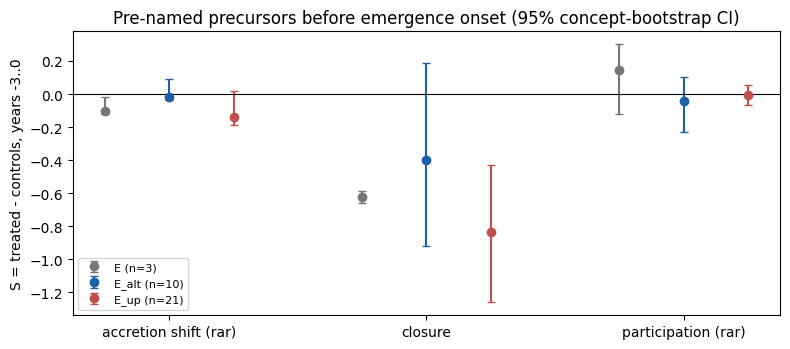

figures/es_precursors_E_up.png


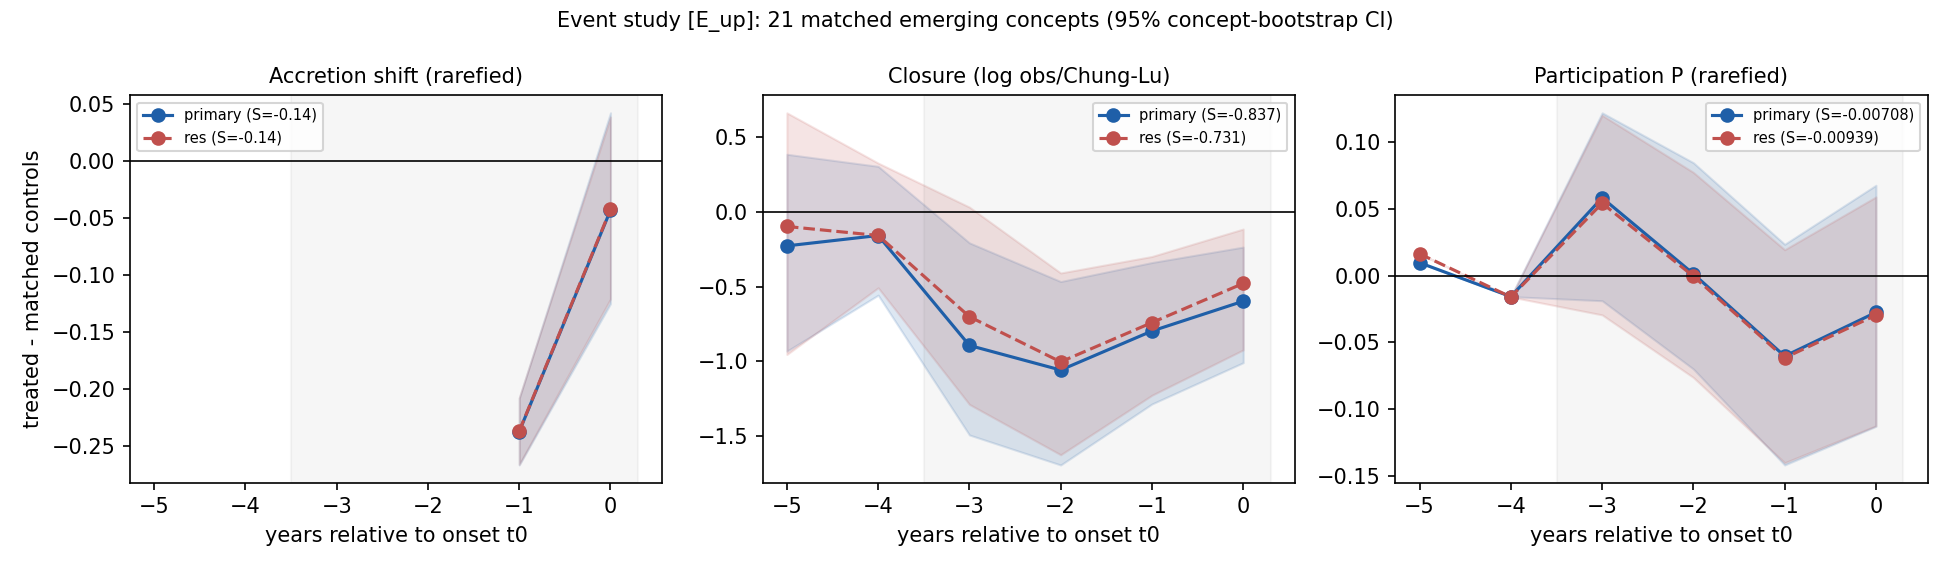

figures/delta_auc.png


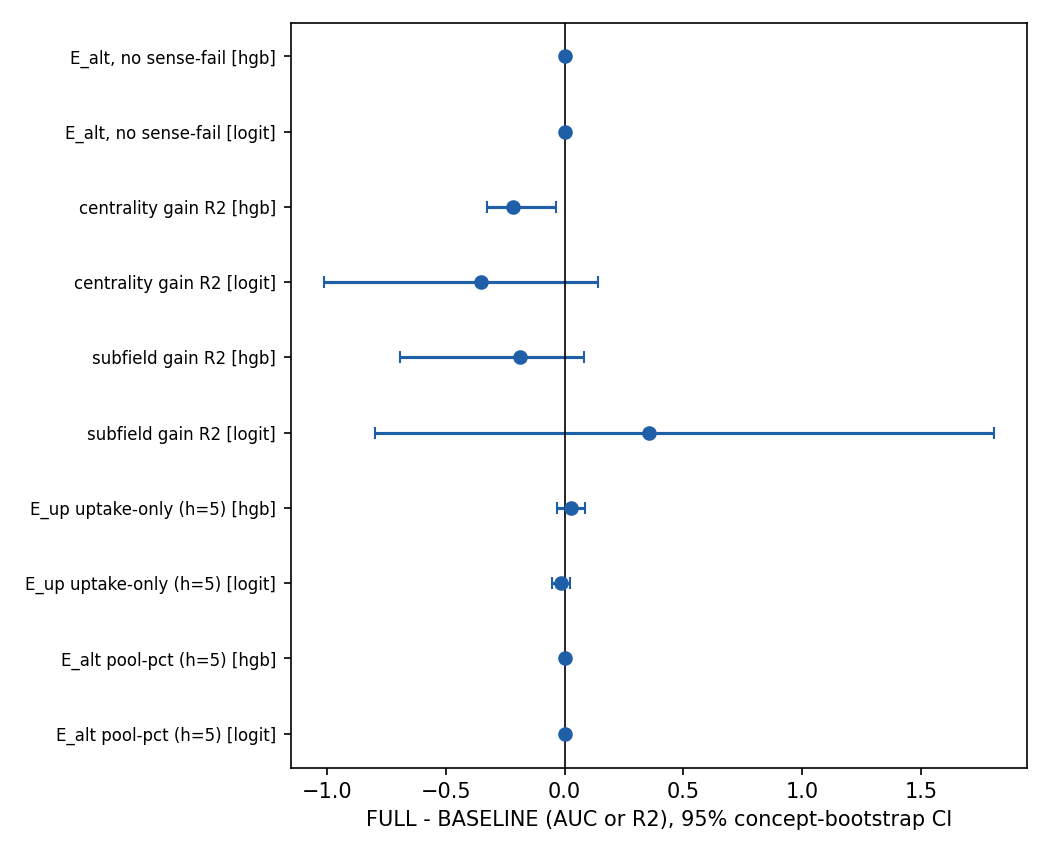

figures/pattern_bars.png


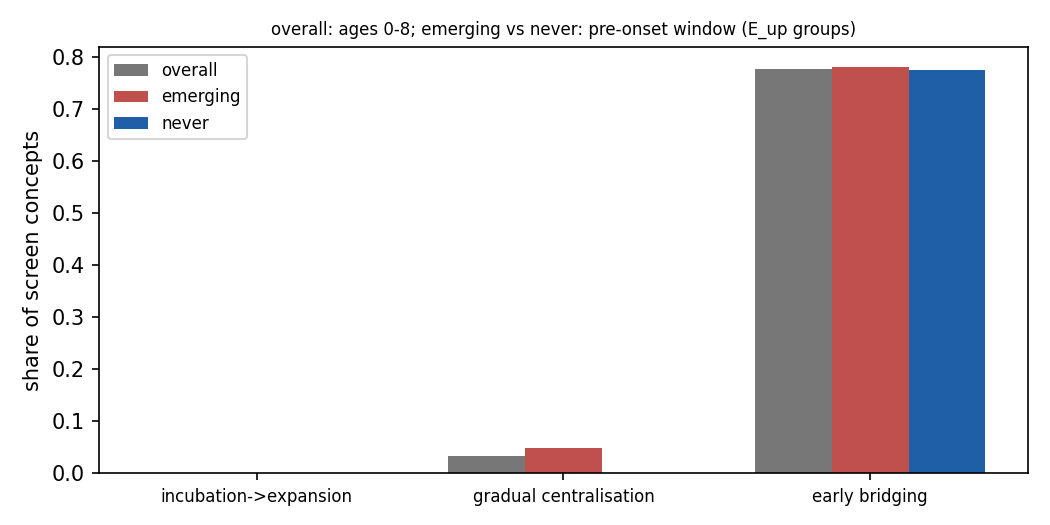

figures/methodology.png


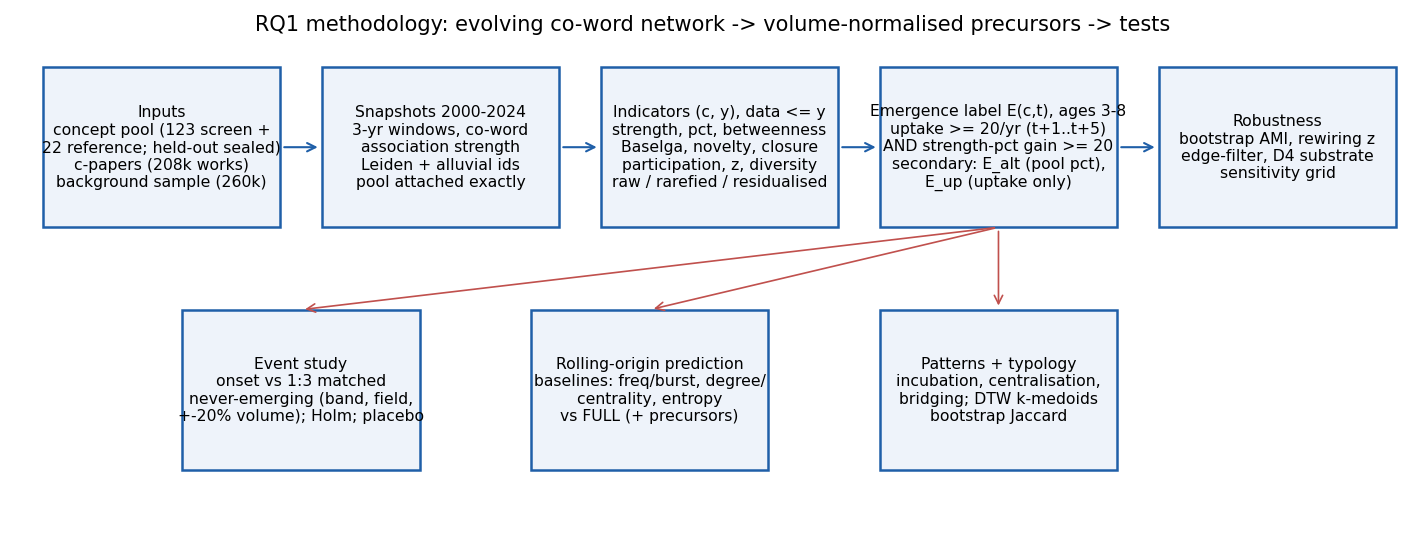

figures/trajectories_E_up.png


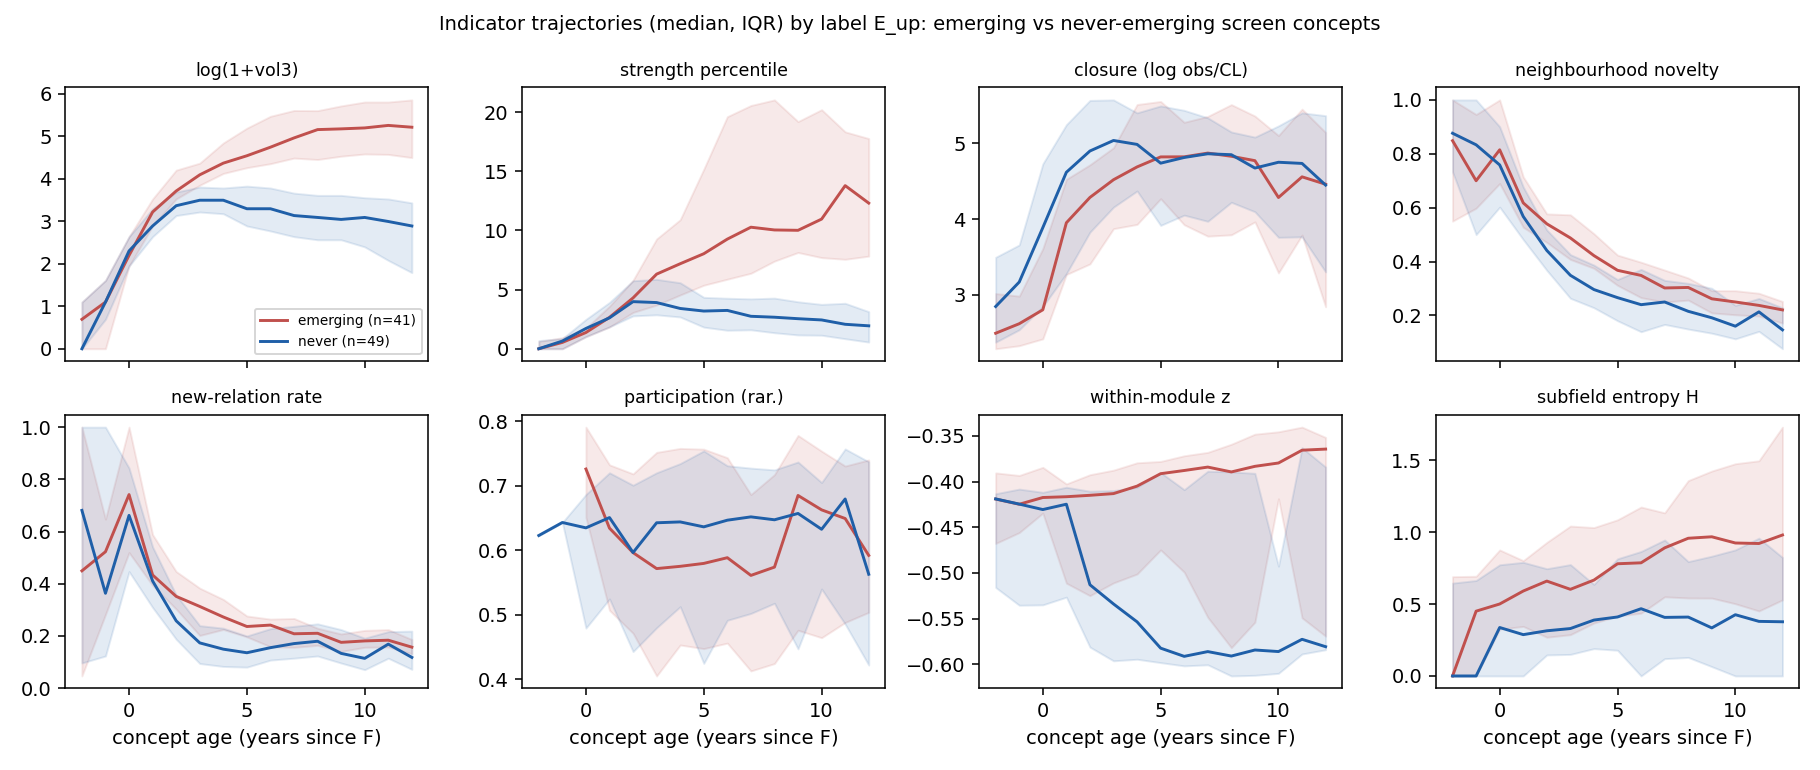

In [25]:
%matplotlib inline
pd.set_option("display.width", 200, "display.max_colwidth", 200)

# 1. label counts per variant
print("Label variants (screen concepts):")
display(pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk != "onset_year_counts"} for k, v in lab_info["variants"].items()}).T)

# 2. event-study table: pre-named precursors + significant exploratory indicators
rows = []
for tag, es in es_all.items():
    for t in es["table"]:
        if t["family"] in ("accretion", "closure", "participation") or (t.get("q_bh") is not None and np.isfinite(t.get("q_bh", np.nan)) and t["q_bh"] < 0.05):
            rows.append(dict(label=tag, family=t["family"], version=t["version"], indicator=t["indicator"], n_treated=t["n_treated"],
                             S=t["S"], ci_lo=t["ci"][0], ci_hi=t["ci"][1], p_holm=t.get("p_holm"), q_bh=t.get("q_bh")))
print("\nEvent study (treated - matched controls, mean over years -3..0):")
display(pd.DataFrame(rows).round(3))

# 3. prediction: pooled AUC of each feature set, logit and HGB
prow = []
for key in ("E_h5", "E_alt_h5", "E_up_h5"):
    for mdl in ("logit", "hgb"):
        ev = pred.get(key, {}).get("eval", {}).get(mdl)
        if not ev:
            continue
        r = {"target": key, "model": mdl, "n_test": ev["n_test_rows"], "pos": ev["n_test_pos"]}
        r.update({fs: v["metric"] for fs, v in ev["pooled"].items()})
        dd = ev["deltas"]["FULL_vs_BASELINE"]
        r.update(dAUC=dd["delta"], dAUC_ci=str(np.round(dd["ci"], 3).tolist()))
        prow.append(r)
print("\nRolling-origin prediction (pooled out-of-sample AUC):")
display(pd.DataFrame(prow).round(3))

# 4. verdicts
print("\nVerdicts:")
for grp, vv in _clean(ver).items():
    print(grp)
    for k, v in vv.items():
        print(f"   {k}: {v}")

# 5. a compact plot: event-study S with 95% CI for every label x precursor
fig, ax = plt.subplots(figsize=(8, 3.6))
lab_tags = list(es_all)
fams = ["accretion", "closure", "participation"]
for j, tag in enumerate(lab_tags):
    tab = {(t["family"], t["version"]): t for t in es_all[tag]["table"]}
    for i, fam in enumerate(fams):
        t = tab[(fam, "primary")]
        if t["S"] is None or not np.isfinite(t["S"]):
            continue
        x = i + (j - 1) * 0.25
        lo, hi = t["ci"]
        err = [[t["S"] - lo], [hi - t["S"]]] if np.isfinite(lo) else None
        ax.errorbar(x, t["S"], yerr=err, fmt="o", capsize=3, color=["#777777", "#1f5fa8", "#c0504d"][j],
                    label=f"{tag} (n={t['n_treated']})" if i == 0 else None)
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(range(3))
ax.set_xticklabels(["accretion shift (rar)", "closure", "participation (rar)"])
ax.set_ylabel("S = treated - controls, years -3..0")
ax.set_title("Pre-named precursors before emergence onset (95% concept-bootstrap CI)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# 6. the figures saved by the original figure code
for f in figs:
    if "methodology" in f or "es_precursors_E_up" in f or "delta_auc" in f or "trajectories_E_up" in f or "pattern_bars" in f:
        print(f)
        display(Image(filename=str(C.ROOT / f)))